<a href="https://colab.research.google.com/github/phungngocbich/phungngocbich.com/blob/code_model_nckh/CNN_GoogleTrends.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install matplotlib-venn
!apt-get -qq install -y libfluidsynth1
# https://pypi.python.org/pypi/libarchive
!apt-get -qq install -y libarchive-dev && pip install -U libarchive
import libarchive
# https://pypi.python.org/pypi/pydot
!apt-get -qq install -y graphviz && pip install pydot
import pydot
!pip install cartopy
import cartopy


E: Package 'libfluidsynth1' has no installation candidate


In [ ]:
pip install pytrends

# **Import thư viện**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, mean_squared_error, r2_score
from keras.models import Sequential
from keras.layers import Conv1D, LSTM, Dense, Dropout

# **LÀM SẠCH DỮ LIỆU**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Load dữ liệu Google Trends (thay thế 'google_trends.csv' bằng file thực tế)
df = pd.read_csv('/content/drive/MyDrive/DATANCKH/trends_filtered_2020_2025.csv', delimiter=',', encoding='utf-8')
df = df.dropna()  # Xóa giá trị NaN nếu có

In [ ]:
# 1. Chuyển đổi cột 'date' sang kiểu datetime
df['date'] = pd.to_datetime(df['date'], errors='coerce')

# 2. Loại bỏ các dòng trùng lặp
df_cleaned = df.drop_duplicates()

# 3. Kiểm tra và loại bỏ các giá trị bị thiếu
df_cleaned = df_cleaned.dropna()

# 4. Chuẩn hóa lại tên cột
df_cleaned.columns = df_cleaned.columns.str.lower().str.replace(" ", "_")

# Lưu lại file đã làm sạch
cleaned_file_path = "DATASET_CLEANED.csv"
df_cleaned.to_csv(cleaned_file_path, index=False)


In [ ]:
#In dữ liệu đã làm sạch
print(df_cleaned)
total_keywords = df['keyword'].nunique() # Thay 'Keyword' bằng tên cột chứa keyword
print(f"Tổng số keyword: {total_keywords}")

            date      keyword  interest_over_time
0     2020-03-15  AI Security                   5
1     2020-03-22  AI Security                   5
2     2020-03-29  AI Security                   5
3     2020-04-05  AI Security                   5
4     2020-04-12  AI Security                   5
...          ...          ...                 ...
12262 2025-02-09   Zero Trust                  74
12263 2025-02-16   Zero Trust                  83
12264 2025-02-23   Zero Trust                  77
12265 2025-03-02   Zero Trust                  74
12266 2025-03-09   Zero Trust                  76

[12267 rows x 3 columns]
Tổng số keyword: 47


# **CNN MODEL**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, mean_squared_error, r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, Flatten, Dense
from tensorflow.keras.optimizers import Adam

In [ ]:
# Kiểm tra dữ liệu
print(df_cleaned)

            date      keyword  interest_over_time
0     2020-03-15  AI Security                   5
1     2020-03-22  AI Security                   5
2     2020-03-29  AI Security                   5
3     2020-04-05  AI Security                   5
4     2020-04-12  AI Security                   5
...          ...          ...                 ...
12262 2025-02-09   Zero Trust                  74
12263 2025-02-16   Zero Trust                  83
12264 2025-02-23   Zero Trust                  77
12265 2025-03-02   Zero Trust                  74
12266 2025-03-09   Zero Trust                  76

[12267 rows x 3 columns]


Chuẩn hóa và chia dữ liệu theo từ khóa

In [ ]:
# Chuẩn hóa dữ liệu
scaler = MinMaxScaler(feature_range=(0, 1))
df_cleaned['trend_value'] = scaler.fit_transform(df_cleaned[['interest_over_time']]) # Replace 'trend_value' with 'Search Interest'
scaler_X = MinMaxScaler()

In [ ]:
# Tạo tập dữ liệu theo từ khóa
keywords = df_cleaned['keyword'].unique()
datasets = {keyword: df_cleaned[df_cleaned['keyword'] == keyword]['trend_value'].values for keyword in keywords}

# Tính tổng số từ khóa
total_keywords = len(keywords)

print("Các từ khóa trong tập dữ liệu:", keywords)
print("Tổng số từ khóa:", total_keywords)

Các từ khóa trong tập dữ liệu: ['AI Security' 'AR Glasses' 'Adaptive learning' 'Applied AI'
 'Augmented reality' 'Bioprinting' 'CRISPR' 'Carbon Capture'
 'Cashless Payment' 'Chatbots' 'Cloud computing for IoT'
 'Cloud computing platforms' 'Computer vision' 'Distributed Cloud'
 'Edge AI' 'FDM' 'Generative AI' 'Green Hydrogen' 'Green cloud computing'
 'Industrial Robots' 'IoT security and trust' 'Lab-grown Meat' 'LiDAR'
 'Metaverse' 'NFT' 'NLP' 'Nano robotics' 'Network Slicing' 'Public Cloud'
 'Quantum Cryptography' 'Quantum computing' 'Qubits' 'RPA Software'
 'Reinforcement Learning' 'Reusable Rockets' 'Small Satellites'
 'Smart Contracts' 'Smart Sensors' 'Smart grid and IoT' 'Super Apps'
 'Synthetic Data' 'Telemedicine' 'V2X' 'VR Headsets' 'Vertical Farming'
 'Virtual reality technology' 'Zero Trust']
Tổng số từ khóa: 47


Áp dụng kỹ thuật Sliding Window

In [ ]:
# Hàm tạo sliding window
def create_sequences(df_cleaned, window_size=10, step_size=5):
    sequences, labels = [], []
    for i in range(len(df_cleaned) - window_size):
        sequences.append(df_cleaned[i:i+window_size])
        labels.append(df_cleaned[i+window_size])
    return np.array(sequences), np.array(labels)

# Định nghĩa window size
window_size = 10
step_size = 5

In [ ]:
# Chia tập train - test theo từng từ khóa
X_train_all = []  # Initialize X_train_all
y_train_all = []  # Initialize y_train_all
X_test_all = []  # Initialize X_test_all
y_test_all = []  # Initialize y_test_all

for keyword in keywords:
    df_cleaned = datasets[keyword]
    X, y = create_sequences(df_cleaned, window_size)

    # Chia train-test 80-20
    split_idx = int(len(X) * 0.8)
    X_train, X_test = X[:split_idx], X[split_idx:]
    y_train, y_test = y[:split_idx], y[split_idx:]

    X_train_all.append(X_train)
    y_train_all.append(y_train)
    X_test_all.append(X_test)
    y_test_all.append(y_test)

    # # In ra tất cả cửa sổ của mỗi từ khóa
    # print(f"\n Từ khóa: {keyword}")
    # print("Tất cả các cửa sổ dữ liệu:")
    # # Loop through each window in X and print it
    # for i in range(len(X)):
    #     print(f"  Window {i+1}: {X[i].flatten()} → {y[i]}")
      # In ra tất cả cửa sổ của mỗi từ khóa
    print(f"\n🔹 {keyword}: Tổng số cửa sổ trượt = {len(X)}")
    for i in range(len(X)):
        print(f"  Window {i+1}: {X[i]} → {y[i]}")

Kết quả truyền trực tuyến bị cắt bớt đến 5000 dòng cuối.
  Window 59: [0.3  0.33 0.29 0.45 0.35 0.42 0.22 0.38 0.29 0.44] → 0.45
  Window 60: [0.33 0.29 0.45 0.35 0.42 0.22 0.38 0.29 0.44 0.45] → 0.45
  Window 61: [0.29 0.45 0.35 0.42 0.22 0.38 0.29 0.44 0.45 0.45] → 0.45
  Window 62: [0.45 0.35 0.42 0.22 0.38 0.29 0.44 0.45 0.45 0.45] → 0.37
  Window 63: [0.35 0.42 0.22 0.38 0.29 0.44 0.45 0.45 0.45 0.37] → 0.35000000000000003
  Window 64: [0.42 0.22 0.38 0.29 0.44 0.45 0.45 0.45 0.37 0.35] → 0.33
  Window 65: [0.22 0.38 0.29 0.44 0.45 0.45 0.45 0.37 0.35 0.33] → 0.29
  Window 66: [0.38 0.29 0.44 0.45 0.45 0.45 0.37 0.35 0.33 0.29] → 0.47000000000000003
  Window 67: [0.29 0.44 0.45 0.45 0.45 0.37 0.35 0.33 0.29 0.47] → 0.3
  Window 68: [0.44 0.45 0.45 0.45 0.37 0.35 0.33 0.29 0.47 0.3 ] → 0.41000000000000003
  Window 69: [0.45 0.45 0.45 0.37 0.35 0.33 0.29 0.47 0.3  0.41] → 0.49
  Window 70: [0.45 0.45 0.37 0.35 0.33 0.29 0.47 0.3  0.41 0.49] → 0.36
  Window 71: [0.45 0.37 0.35 0.33 0

In [ ]:
# Gộp dữ liệu từ tất cả các từ khóa
X_train_all = [x for x in X_train_all if x.size > 0]  # Remove empty arrays
y_train_all = [y for y in y_train_all if y.size > 0]  # Remove empty arrays
X_test_all = [x for x in X_test_all if x.size > 0]  # Remove empty arrays
y_test_all = [y for y in y_test_all if y.size > 0]  # Remove empty arrays

X_train = np.concatenate(X_train_all)
y_train = np.concatenate(y_train_all)
X_test = np.concatenate(X_test_all)
y_test = np.concatenate(y_test_all)

In [ ]:
# Định dạng lại dữ liệu cho CNN
X_train_reshaped = X_train.reshape(-1, X_train.shape[-1])  # Reshape for StandardScaler
X_test_reshaped = X_test.reshape(-1, X_test.shape[-1])  # Reshape similarly

X_train_scaled = scaler_X.fit_transform(X_train_reshaped).reshape(X_train.shape)
X_test_scaled = scaler_X.transform(X_test_reshaped).reshape(X_test.shape)

Xây dựng mô hình CNN

In [ ]:
model = Sequential([
    Conv1D(filters=64, kernel_size=3, activation='relu', input_shape=(window_size, 1)),
    Flatten(),
    Dense(50, activation='relu'),
    Dense(1)
])

model.compile(optimizer=Adam(learning_rate=0.001), loss='mse')
model.summary()


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv1d_6 (Conv1D)                    │ (None, 8, 64)               │             256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_4 (Flatten)                  │ (None, 512)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_8 (Dense)                      │ (None, 50)                  │          25,650 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_9 (Dense)                      │ (None, 1)                   │              51 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 25,957 (101.39 KB)

 Trainable params: 25,957 (101.39 KB)

 Non-trainable params: 0 (0.00 B)

Dự đoán và đánh giá mô hình

In [ ]:
# Dự đoán kết quả
y_pred = model.predict(X_test)

75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


In [ ]:
# Chuyển về thang đo gốc
y_pred_original = scaler.inverse_transform(y_pred.reshape(-1, 1))
y_test_original = scaler.inverse_transform(y_test.reshape(-1, 1))

In [ ]:
# Khởi tạo bộ chuẩn hóa MinMaxScaler
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

# Chuẩn hóa dữ liệu đầu vào X
X_train_reshaped = X_train.reshape(-1, X_train.shape[-1])  # Reshape để fit MinMaxScaler
X_test_reshaped = X_test.reshape(-1, X_test.shape[-1])  # Reshape tương tự

X_train_scaled = scaler_X.fit_transform(X_train_reshaped).reshape(X_train.shape)
X_test_scaled = scaler_X.transform(X_test_reshaped).reshape(X_test.shape)

# Chuẩn hóa dữ liệu đầu ra y
y_train_scaled = scaler_y.fit_transform(y_train.reshape(-1, 1)).flatten()
y_test_scaled = scaler_y.transform(y_test.reshape(-1, 1)).flatten()


In [ ]:
from tensorflow.keras.layers import Conv1D, Flatten, Dense, Dropout # Import Dropout
# 🔹 Xây dựng mô hình CNN
model = Sequential([
    Conv1D(filters=64, kernel_size=3, activation='relu', input_shape=(X_train.shape[1], 1)), # Add a features dimension of 1
    Conv1D(filters=128, kernel_size=3, activation='relu'),
    Flatten(),
    Dense(64, activation='relu'),
    Dropout(0.2), # Now Dropout should be recognized
    Dense(1)  # Dự đoán giá trị tiếp theo
])

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
# 🔹 Sử dụng Adam với learning rate thấp để tối ưu hóa
optimizer = Adam(learning_rate=0.001)

# 🔹 Compile mô hình
model.compile(optimizer=optimizer, loss='mse')

In [ ]:
# 🔹 Huấn luyện mô hình
history = model.fit(X_train_scaled, y_train_scaled, epochs=50, batch_size=16, validation_data=(X_test_scaled, y_test_scaled))

Epoch 1/50
588/588 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - loss: 0.0157 - val_loss: 0.0099
Epoch 2/50
588/588 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - loss: 0.0107 - val_loss: 0.0106
Epoch 3/50
588/588 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.0087 - val_loss: 0.0143
Epoch 4/50
588/588 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 0.0095 - val_loss: 0.0096
Epoch 5/50
588/588 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - loss: 0.0094 - val_loss: 0.0096
Epoch 6/50
588/588 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.0084 - val_loss: 0.0144
Epoch 7/50
588/588 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - loss: 0.0084 - val_loss: 0.0111
Epoch 8/50
588/588 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - loss: 0.0084 - val_loss: 0.0096
Epoch 9/50
588/588 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - loss: 0.0084 - val_loss: 0.0115
Epoch 10/50
588/588 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - loss: 0.0080 - val_loss: 0.0101
Epoch 11/50
588/588 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - loss: 0.0079 - val_loss: 0.0099
Epoch 12/50
588/588 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step

In [ ]:
# 🔹 Dự đoán
y_pred_scaled = model.predict(X_test_scaled)

# 🔹 Chuyển dữ liệu về giá trị ban đầu
y_test_original = scaler_y.inverse_transform(y_test_scaled.reshape(-1, 1)).flatten()
y_pred_original = scaler_y.inverse_transform(y_pred_scaled).flatten()


75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


In [ ]:
# Tính các chỉ số đánh giá
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Hàm tính MAPE tránh chia cho 0
def mean_absolute_percentage_error(y_true, y_pred):
    mask = y_true != 0  # Chỉ tính MAPE cho các giá trị y_true khác 0
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

# Hàm đánh giá mô hình
def evaluate_model(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    mape = mean_absolute_percentage_error(y_true, y_pred)  # Dùng MAPE đã sửa lỗi
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    return mae, mape, rmse, r2

# Tính lại các chỉ số
mae, mape, rmse, r2 = evaluate_model(y_test_original, y_pred_original)

# In kết quả mới
print("\n--- Đánh giá mô hình CNN ---")
print(f"MAE: {mae}")
print(f"MAPE: {mape}%")
print(f"RMSE: {rmse}")
print(f"R2 Score: {r2}")



--- Đánh giá mô hình CNN ---
MAE: 0.059510830920290636
MAPE: 15.13176913643515%
RMSE: 0.10184454875948261
R2 Score: 0.8555927930670195


In [ ]:
from sklearn.preprocessing import MinMaxScaler

# Khởi tạo scaler cho dữ liệu đầu vào và đầu ra
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()


In [ ]:
# Hàm tính MAPE tránh chia cho 0
def mean_absolute_percentage_error(y_true, y_pred):
    mask = y_true != 0  # Chỉ tính MAPE cho các giá trị y_true khác 0
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


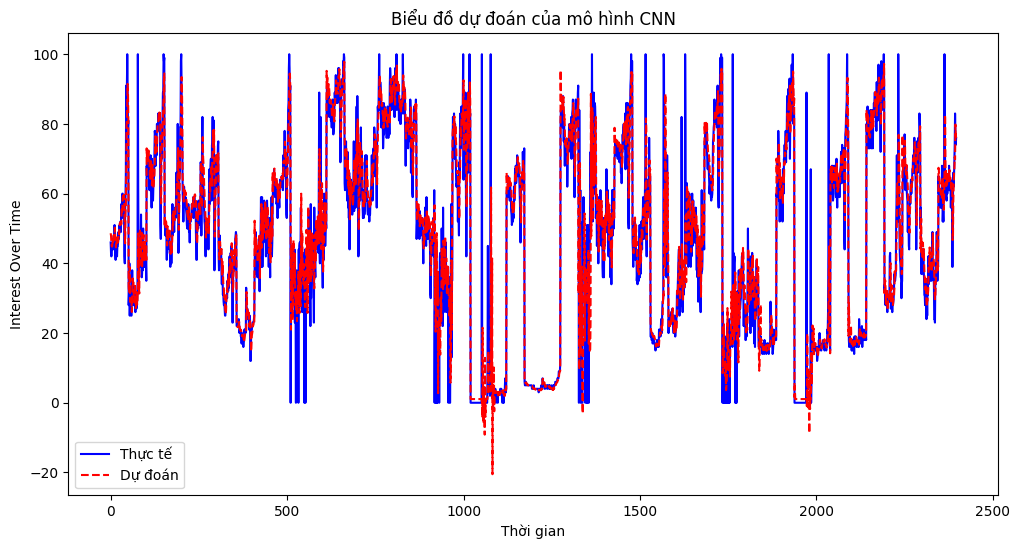

In [ ]:
# Dự đoán kết quả với mô hình CNN
y_pred = model.predict(X_test)

# Chuyển về thang đo gốc
y_pred_original = scaler.inverse_transform(y_pred.reshape(-1, 1))
y_test_original = scaler.inverse_transform(y_test.reshape(-1, 1))

# Vẽ biểu đồ dự đoán cho mô hình CNN
plt.figure(figsize=(12, 6))
plt.plot(y_test_original, label="Thực tế", color='blue')
plt.plot(y_pred_original, label="Dự đoán", color='red', linestyle='dashed')
plt.title("Biểu đồ dự đoán của mô hình CNN")
plt.xlabel("Thời gian")
plt.ylabel("Interest Over Time")
plt.legend()
plt.show()

In [ ]:
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Hàm tính MAPE tránh chia cho 0
def mean_absolute_percentage_error(y_true, y_pred):
    mask = y_true != 0  # Chỉ tính MAPE cho các giá trị y_true khác 0
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

# Hàm đánh giá mô hình
def evaluate_model(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    mape = mean_absolute_percentage_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    return mae, mape, rmse, r2

# Duyệt từng từ khóa và tính các chỉ số đánh giá
results = {}
# Use the original DataFrame (df) to get unique keywords
keywords = df['keyword'].unique()  # Changed from df_cleaned to df
for keyword in keywords:
    # Filter the original DataFrame (df) to get data for the current keyword
    filtered_df = df[df['keyword'] == keyword]  # Added this line

    # Get scaled trend values from the filtered DataFrame
    # Instead of 'trend_value_scaled', use the actual column name 'interest_over_time'
    data = filtered_df['interest_over_time'].values
    X, y = create_sequences(data, window_size, step_size)
    X = X.reshape((X.shape[0], X.shape[1], 1))

    y_pred_keyword = model.predict(X)

    # Chuyển đổi về thang đo gốc
    y_pred_keyword_original = scaler_y.inverse_transform(y_pred_keyword.reshape(-1, 1))
    y_original = scaler_y.inverse_transform(y.reshape(-1, 1))

    # Tính các chỉ số đánh giá
    mae, mape, rmse, r2 = evaluate_model(y_original, y_pred_keyword_original)
    results[keyword] = (mae, mape, rmse, r2)

# In kết quả đánh giá cho từng từ khóa
print("\n--- Đánh giá mô hình CNN cho từng từ khóa ---")
for keyword, (mae, mape, rmse, r2) in results.items():
    print(f"\n🔹 {keyword}:")
    print(f"   ✅ MAE: {mae}")
    print(f"   ✅ MAPE: {mape}%")
    print(f"   ✅ RMSE: {rmse}")
    print(f"   ✅ R2 Score: {r2}")

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
8/8 ━━━━━━━━

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


<ipython-input-157-0f811f9089cf>:42: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


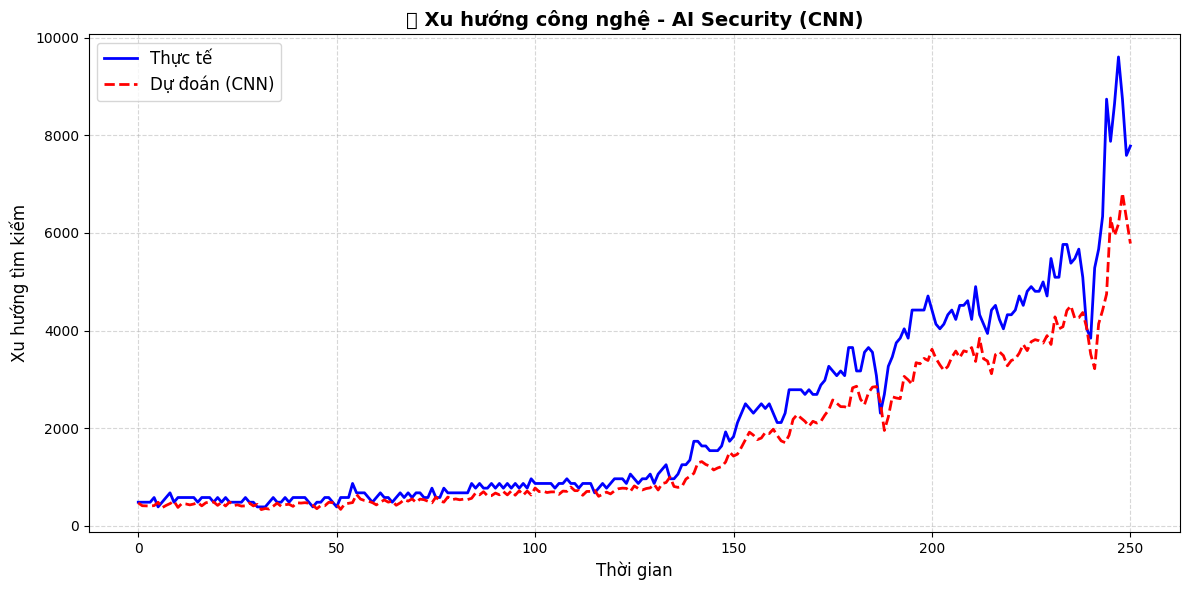

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 


<ipython-input-157-0f811f9089cf>:42: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


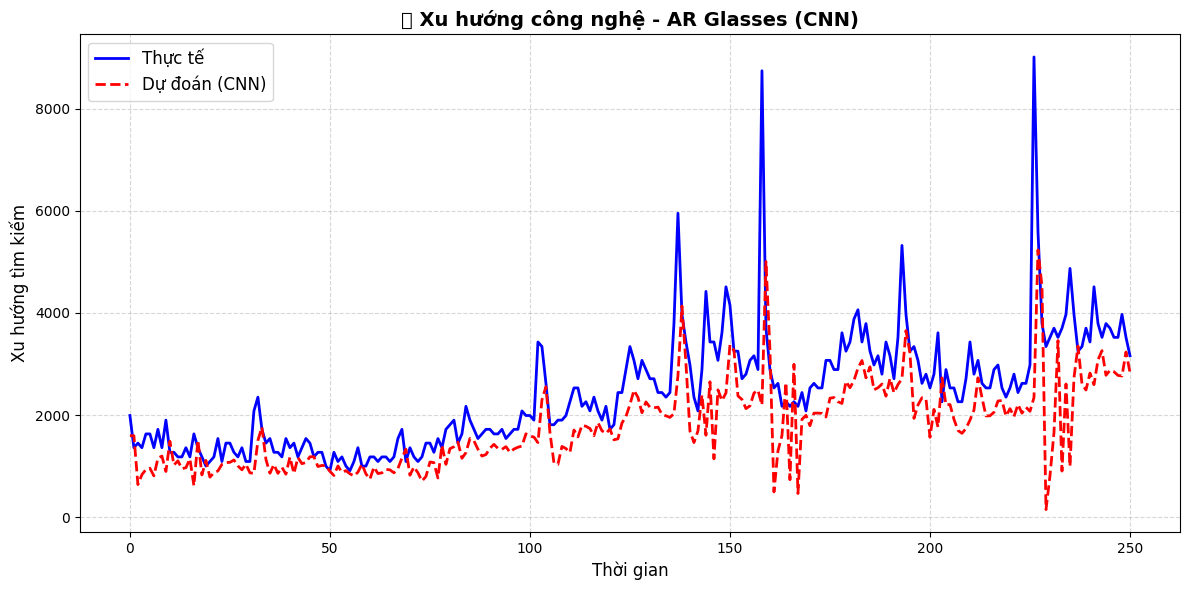

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 


<ipython-input-157-0f811f9089cf>:42: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


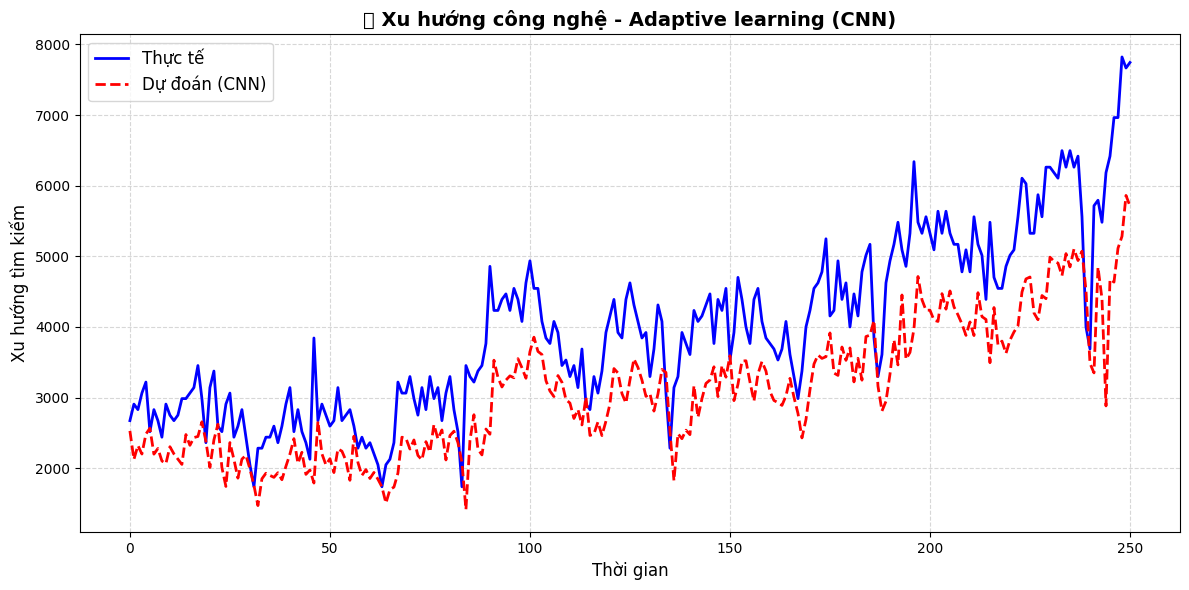

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 


<ipython-input-157-0f811f9089cf>:42: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


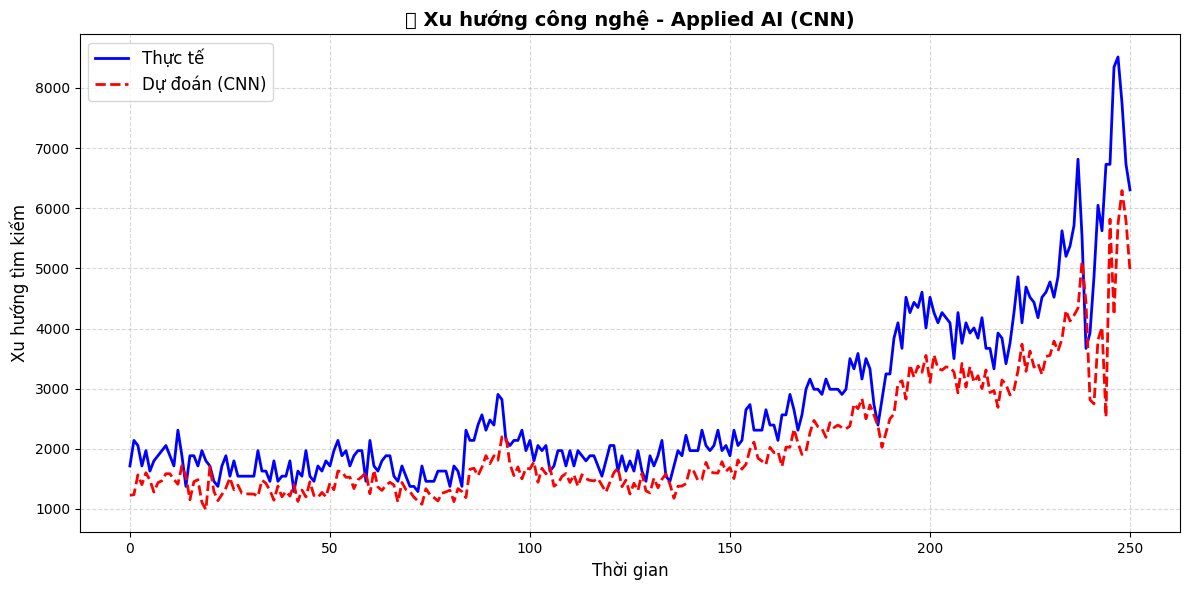

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 


<ipython-input-157-0f811f9089cf>:42: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


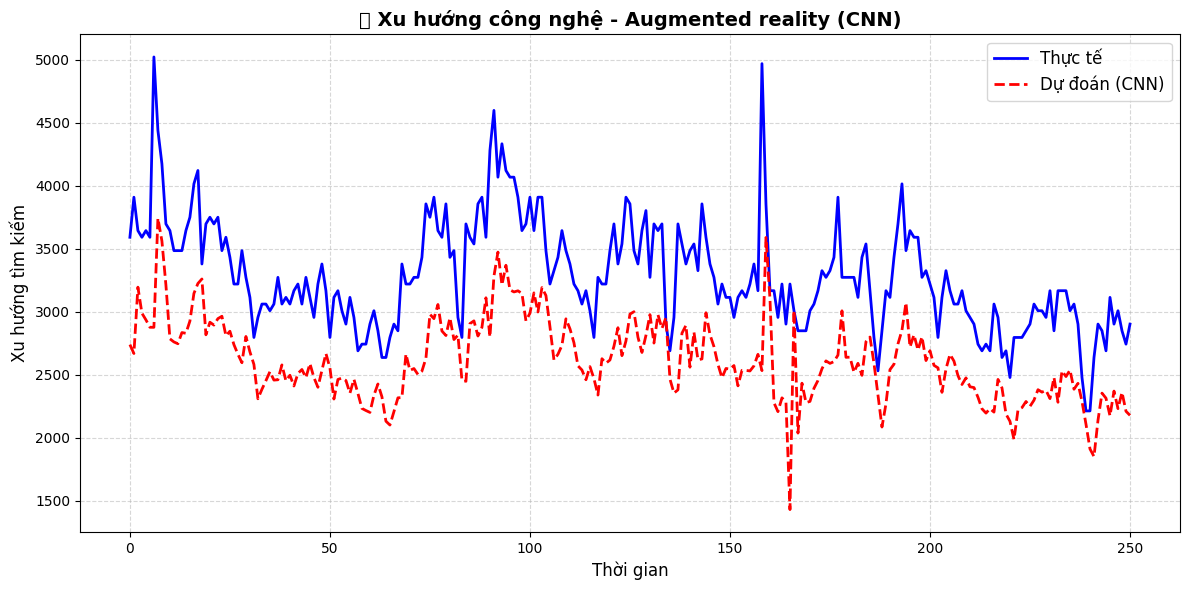

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 


<ipython-input-157-0f811f9089cf>:42: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


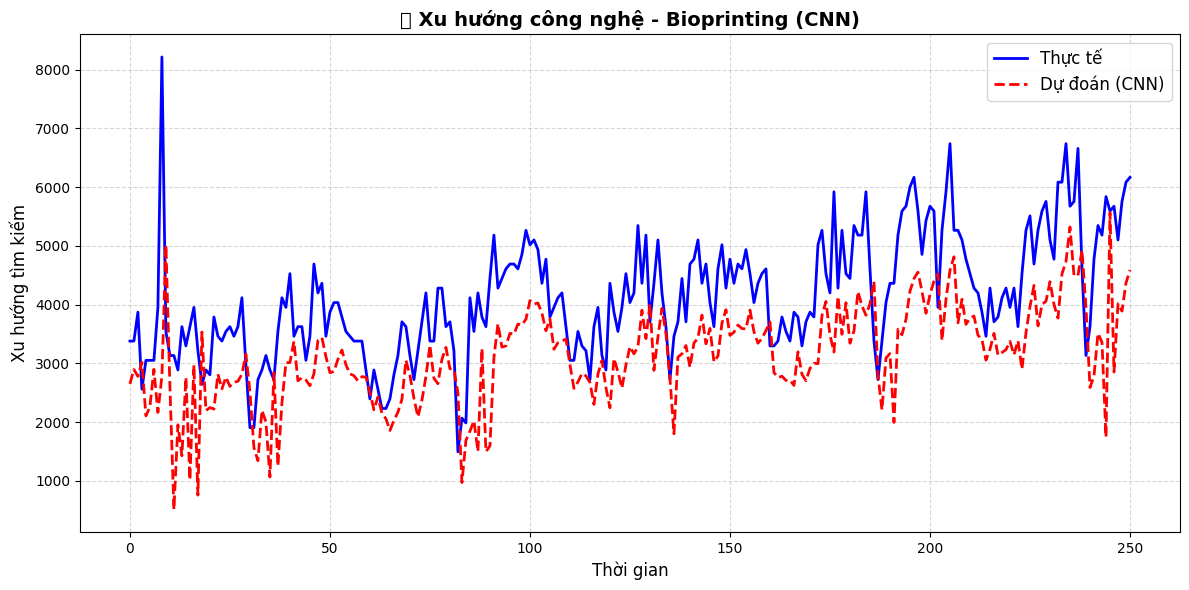

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 


<ipython-input-157-0f811f9089cf>:42: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


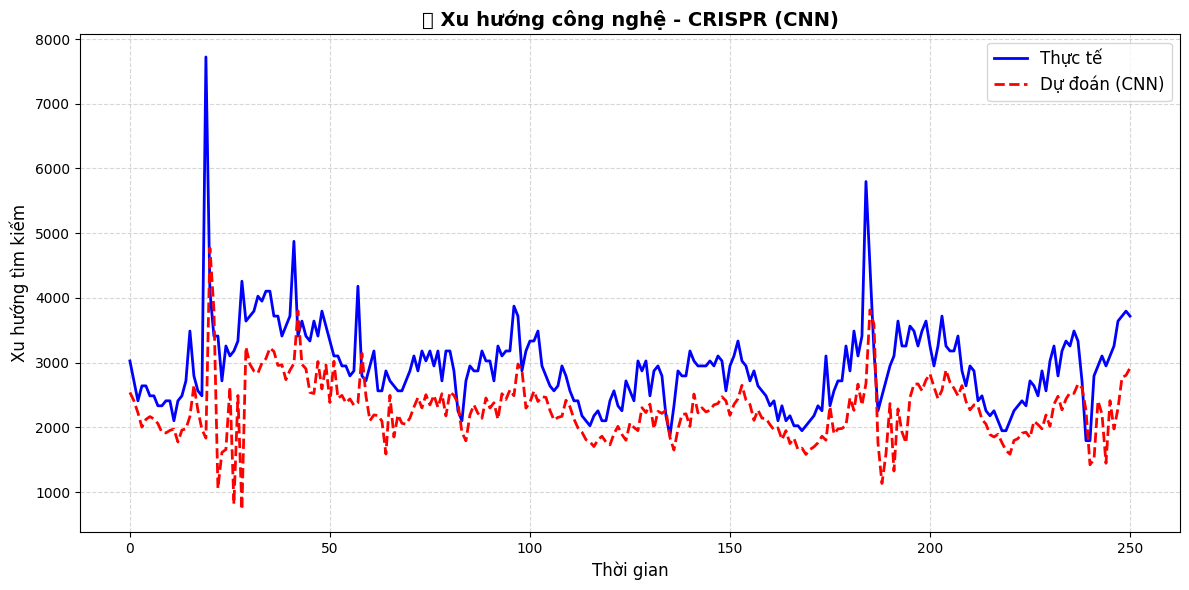

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 


<ipython-input-157-0f811f9089cf>:42: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


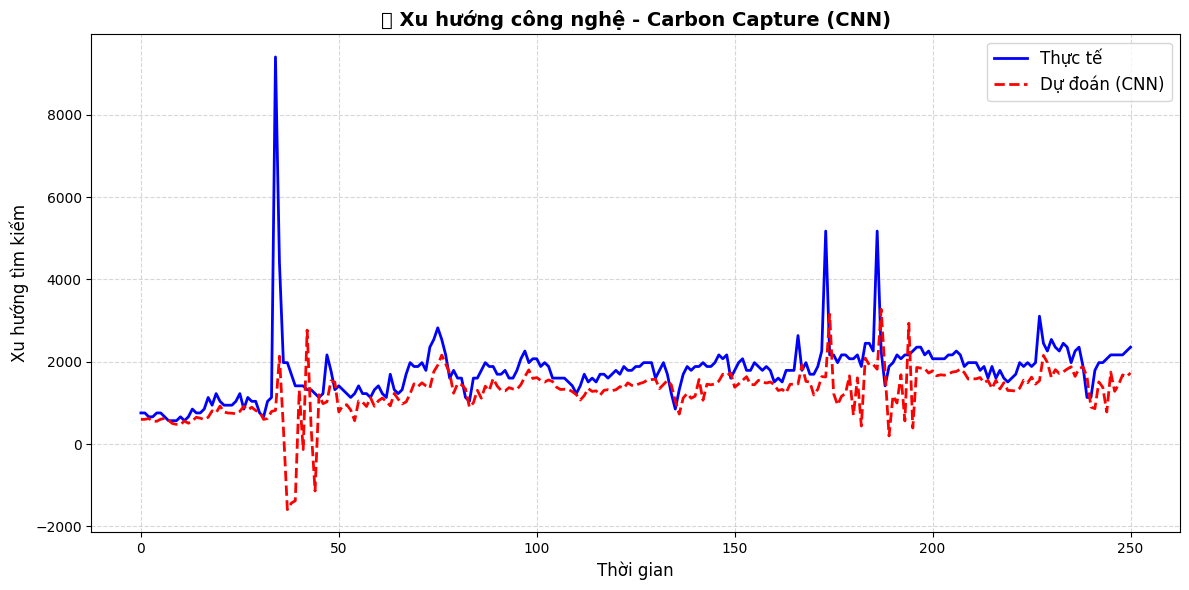

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 


<ipython-input-157-0f811f9089cf>:42: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


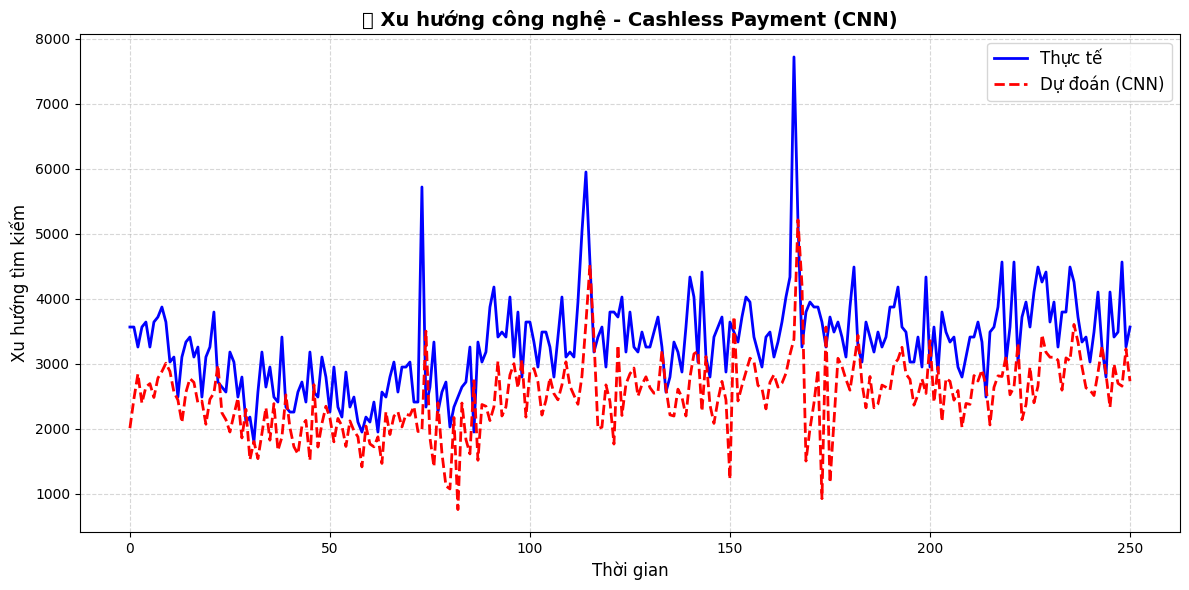

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 


<ipython-input-157-0f811f9089cf>:42: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


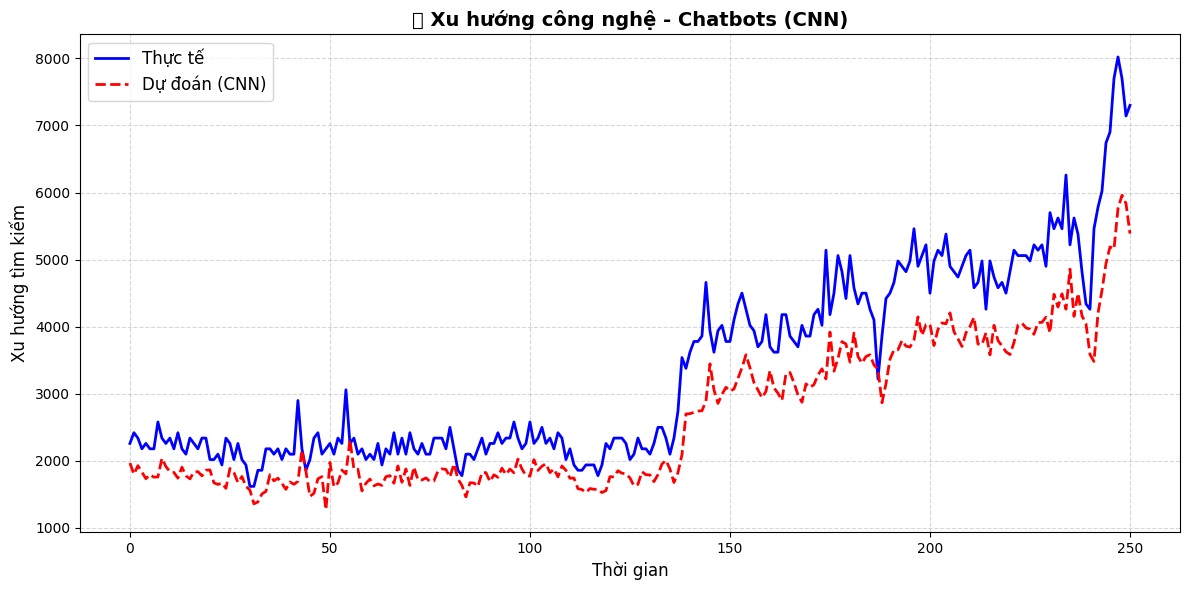

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 


<ipython-input-157-0f811f9089cf>:42: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


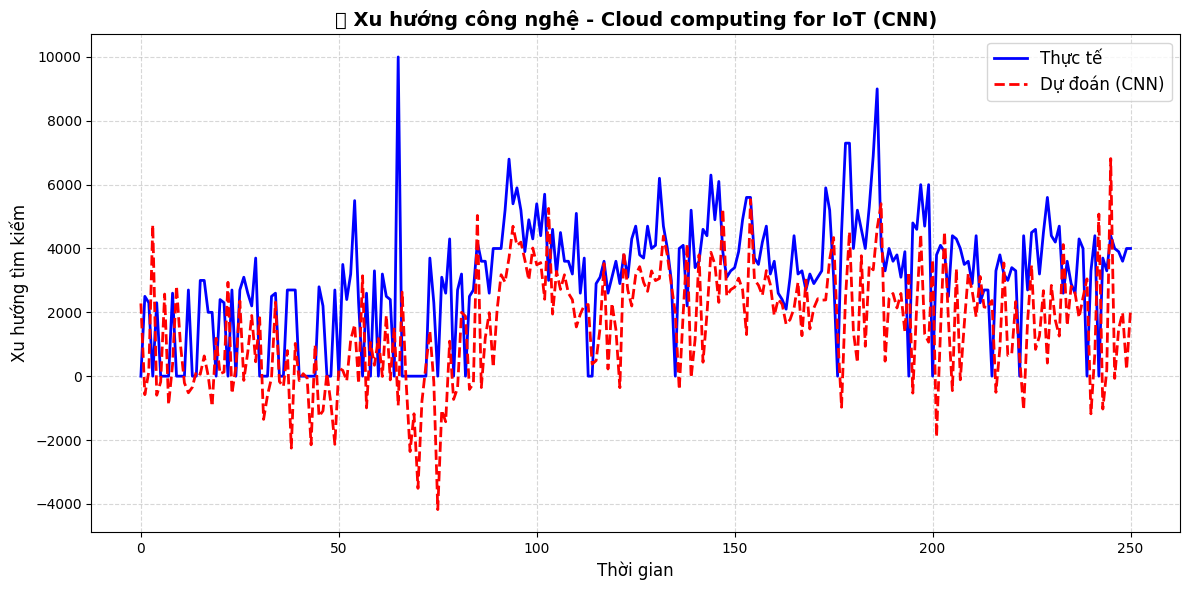

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 


<ipython-input-157-0f811f9089cf>:42: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


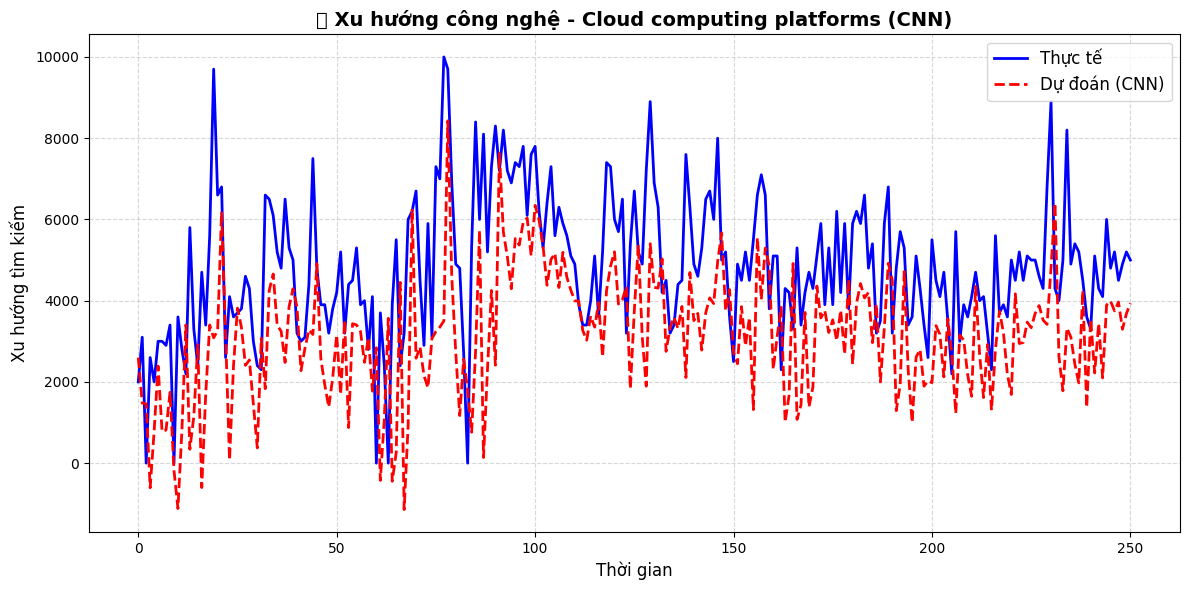

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 


<ipython-input-157-0f811f9089cf>:42: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


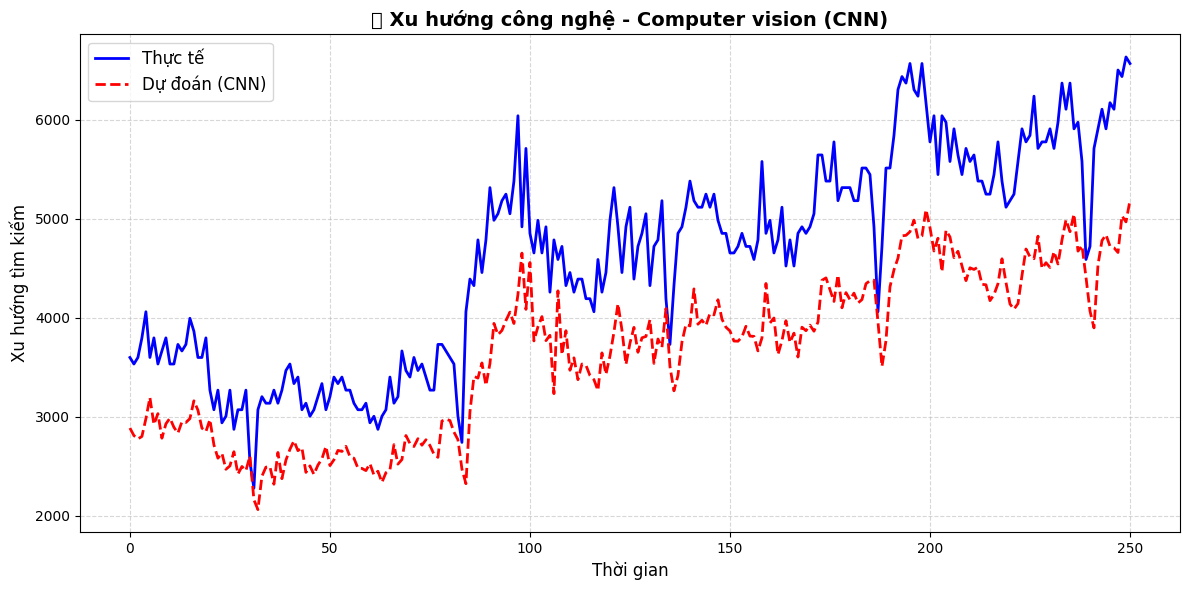

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 


<ipython-input-157-0f811f9089cf>:42: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


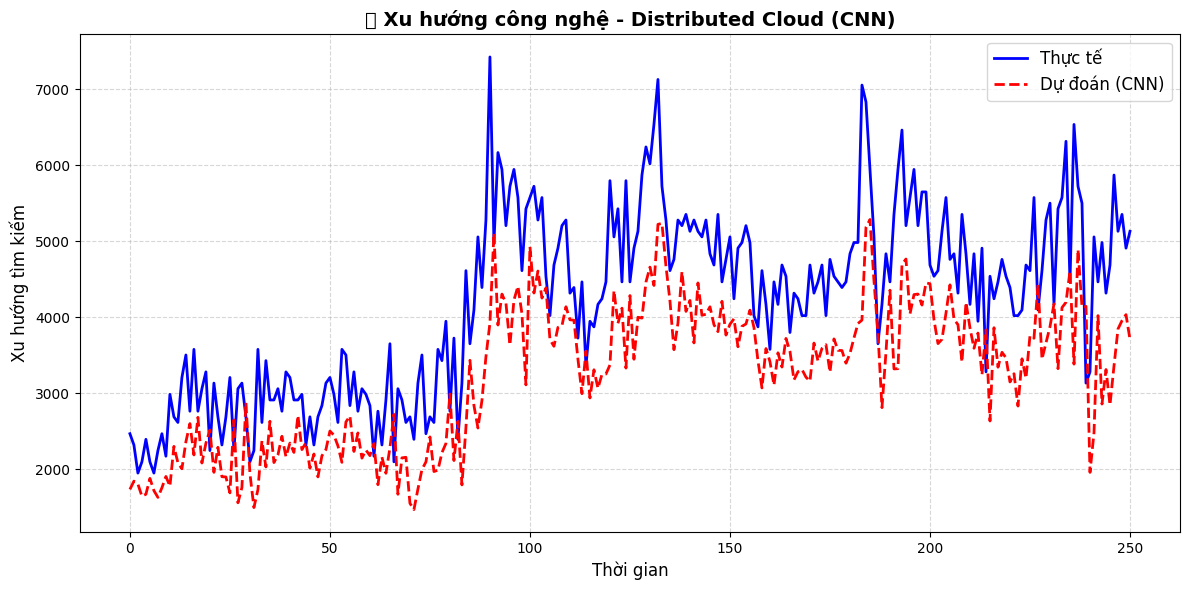

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 


<ipython-input-157-0f811f9089cf>:42: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


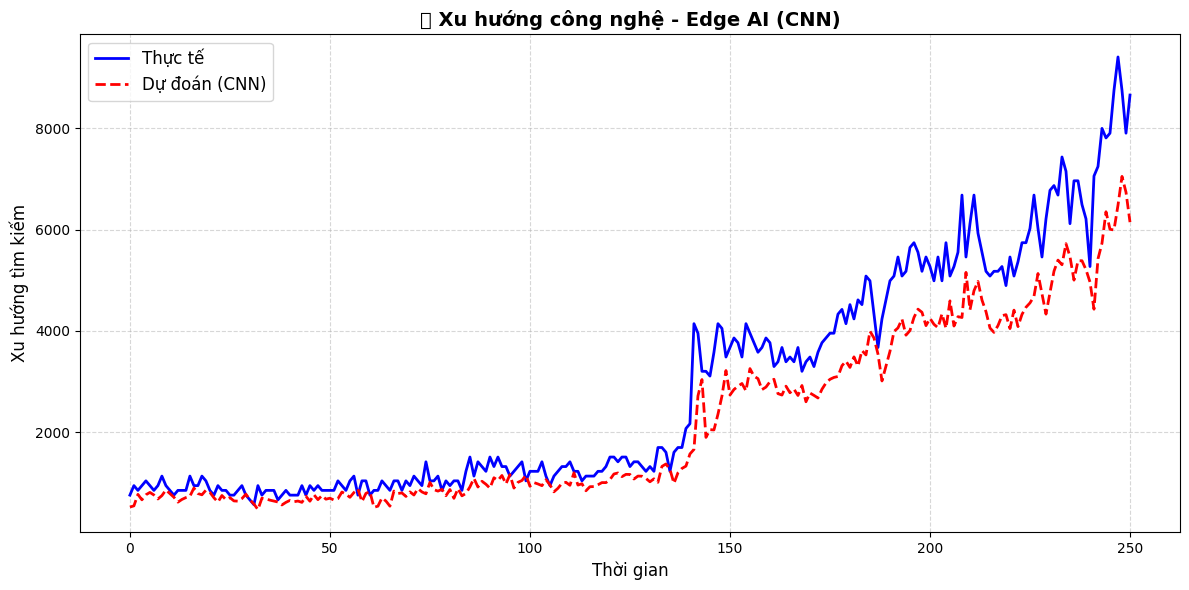

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 


<ipython-input-157-0f811f9089cf>:42: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


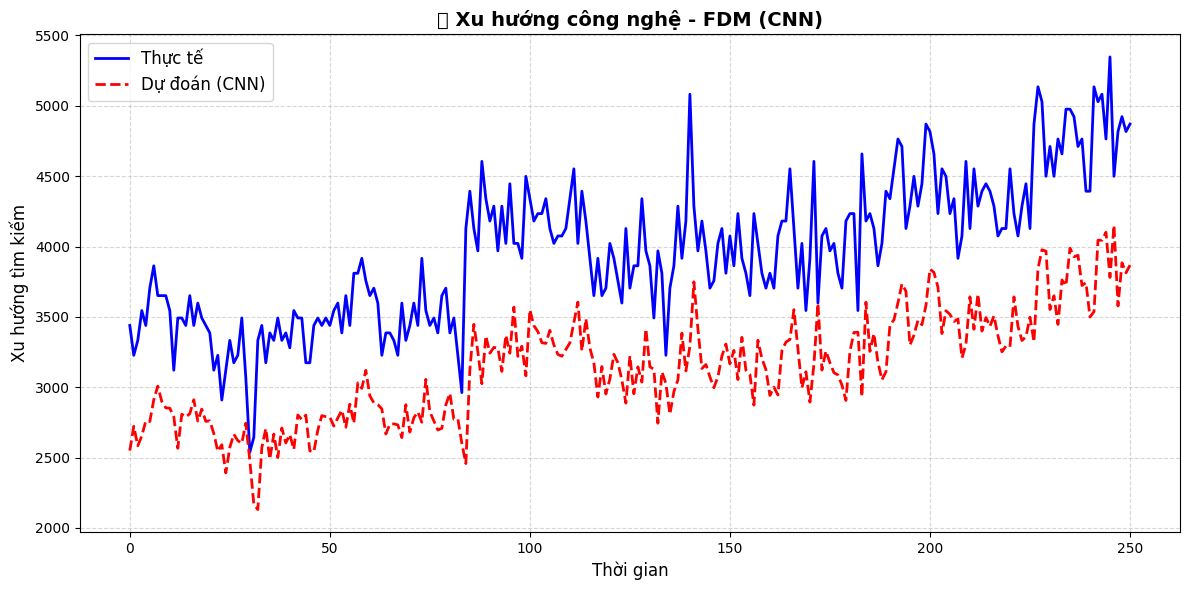

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 


<ipython-input-157-0f811f9089cf>:42: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


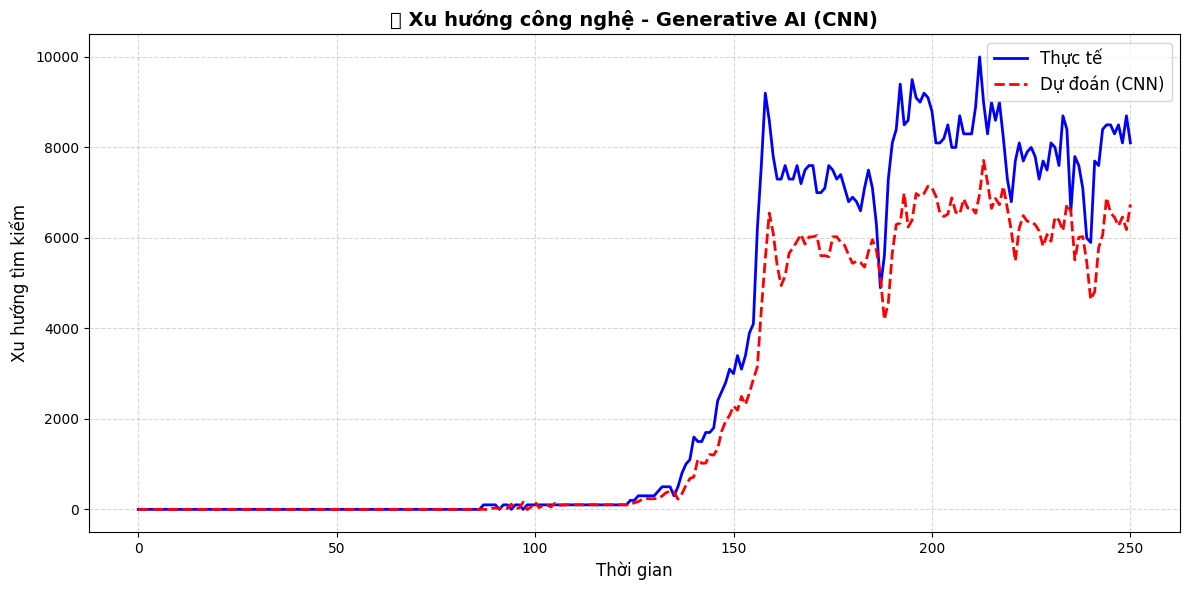

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 


<ipython-input-157-0f811f9089cf>:42: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


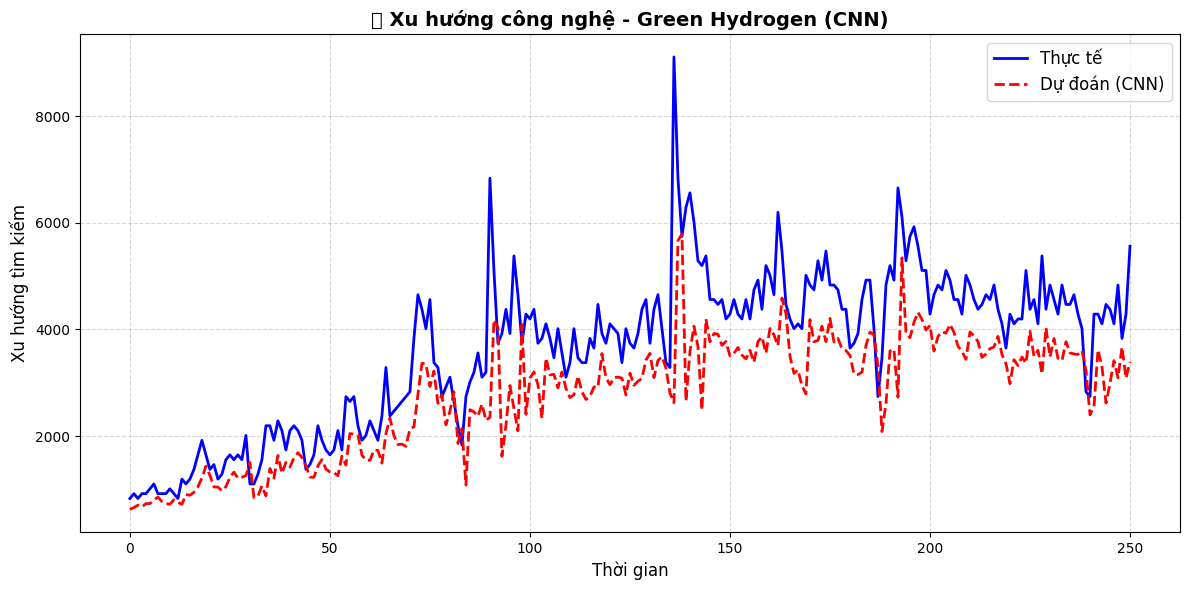

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 


<ipython-input-157-0f811f9089cf>:42: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


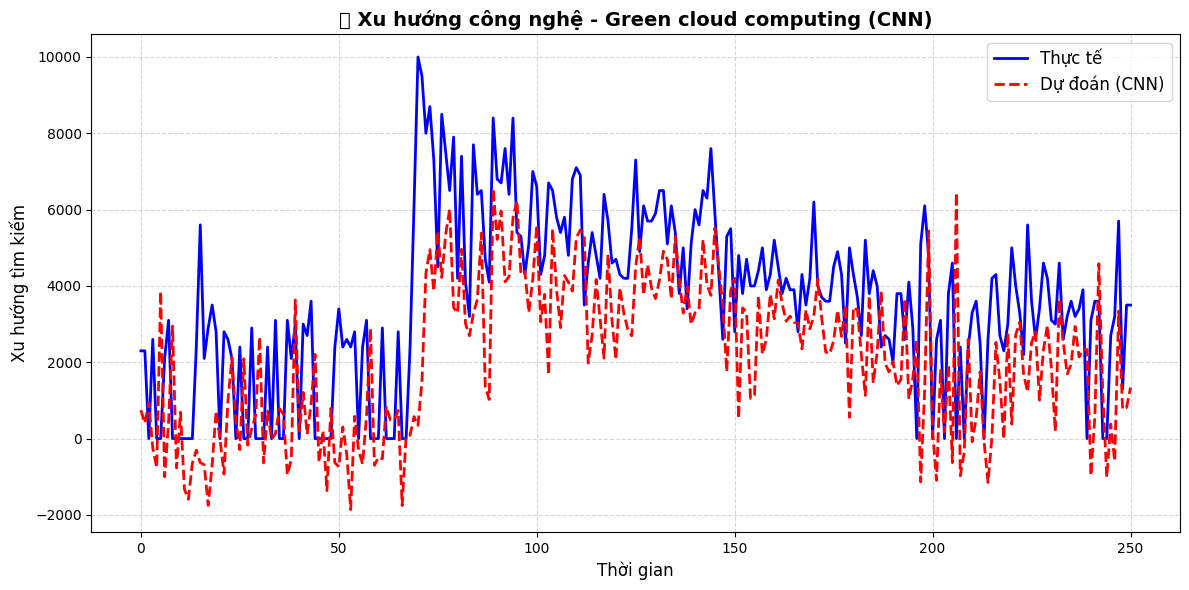

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step


<ipython-input-157-0f811f9089cf>:42: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


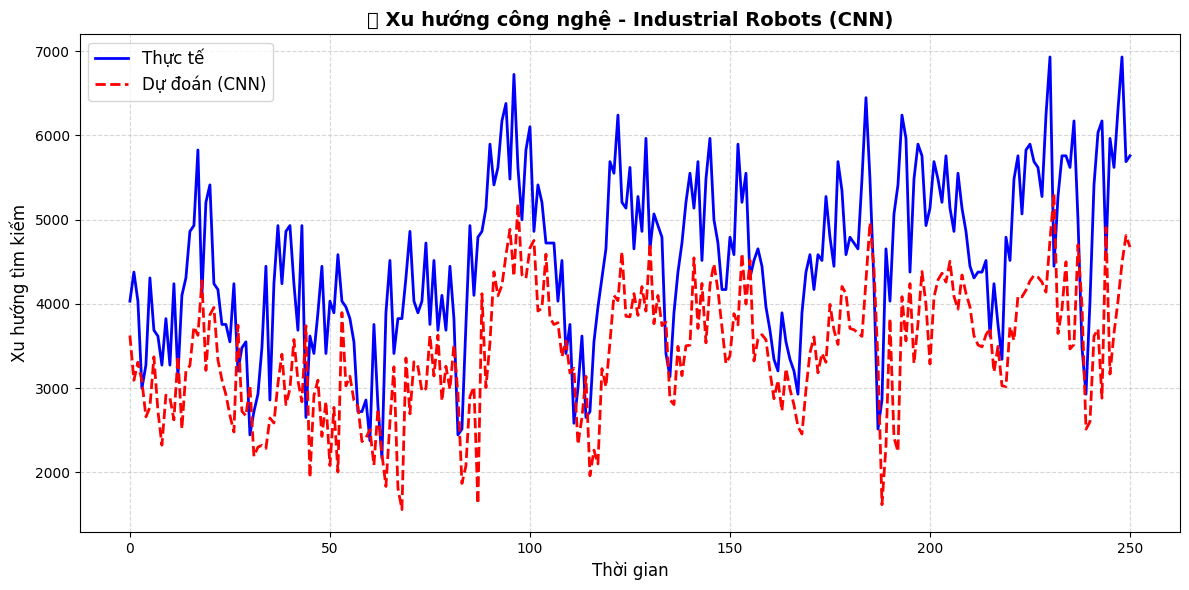

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 


<ipython-input-157-0f811f9089cf>:42: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


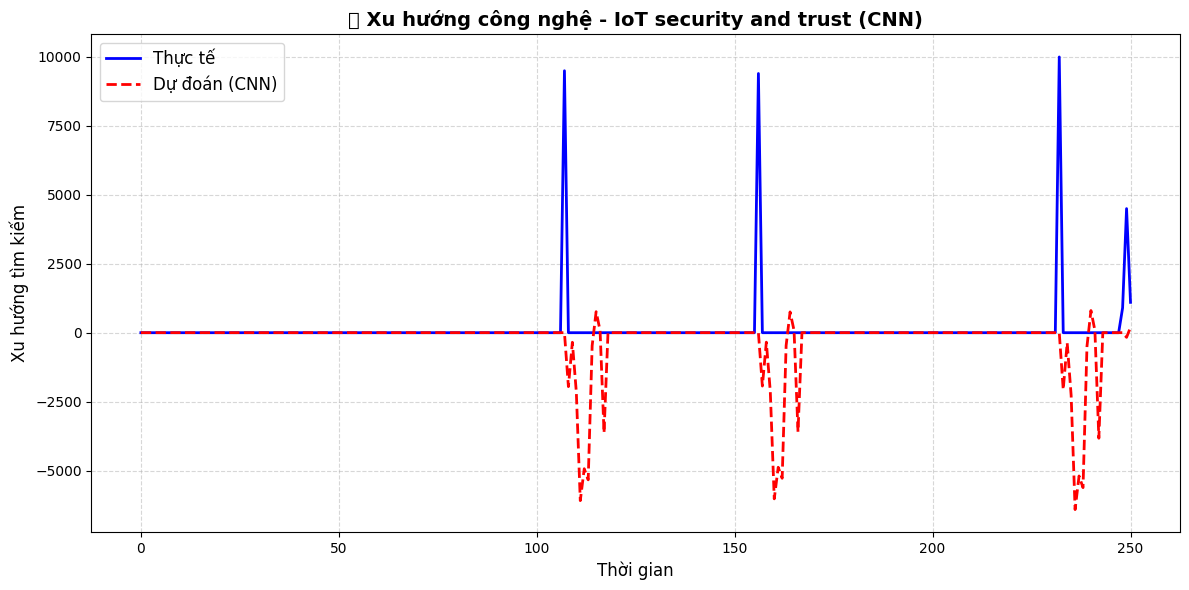

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 


<ipython-input-157-0f811f9089cf>:42: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


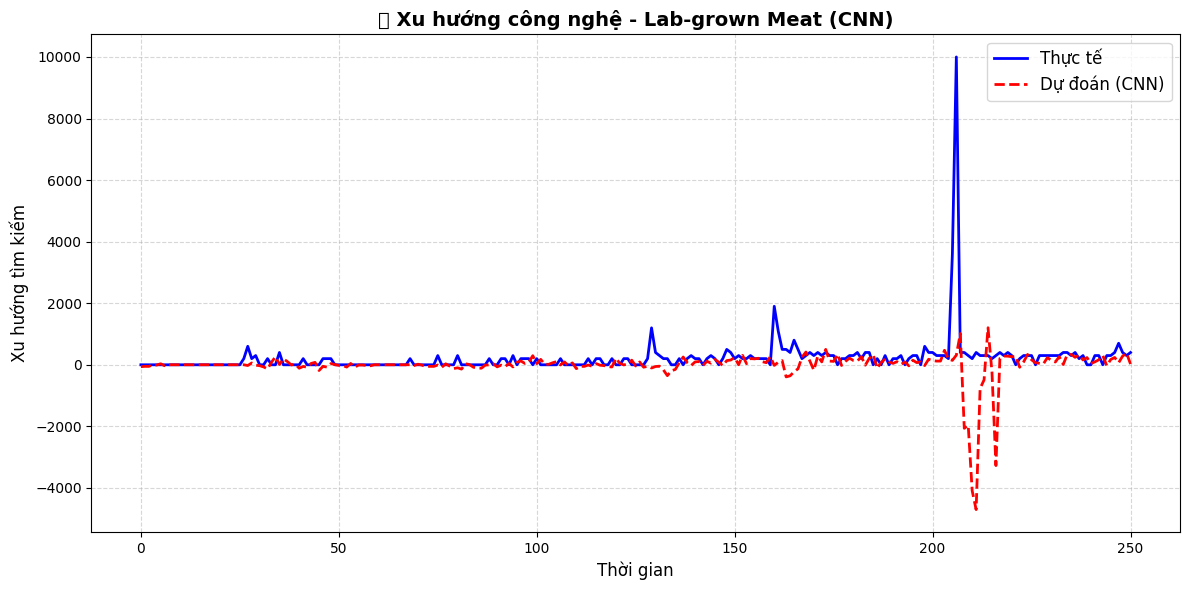

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step


<ipython-input-157-0f811f9089cf>:42: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


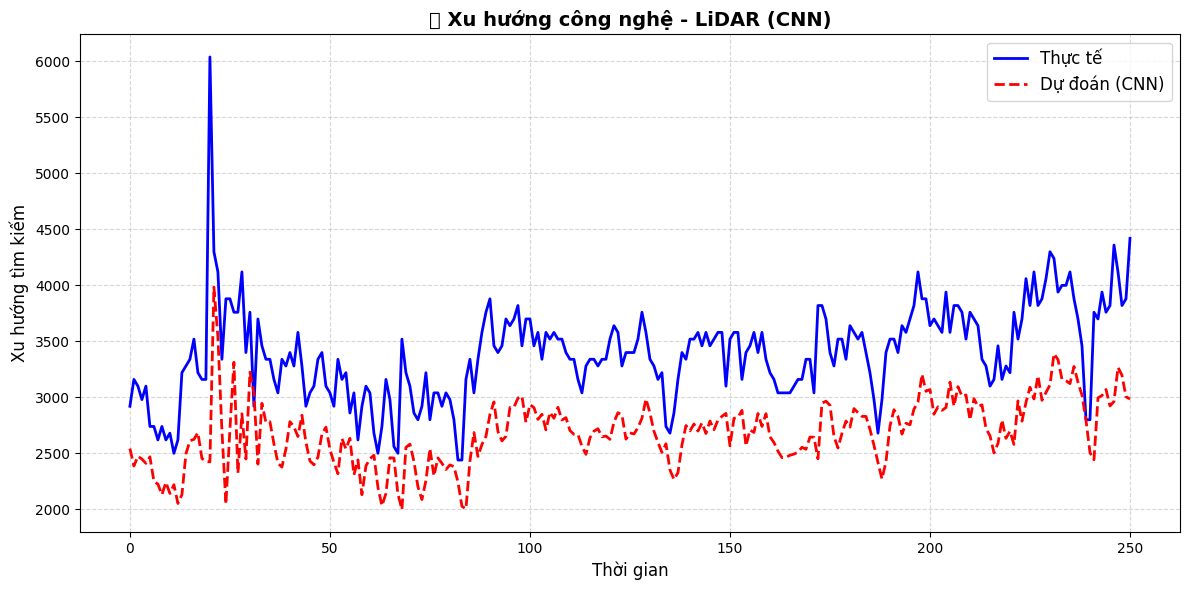

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 


<ipython-input-157-0f811f9089cf>:42: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


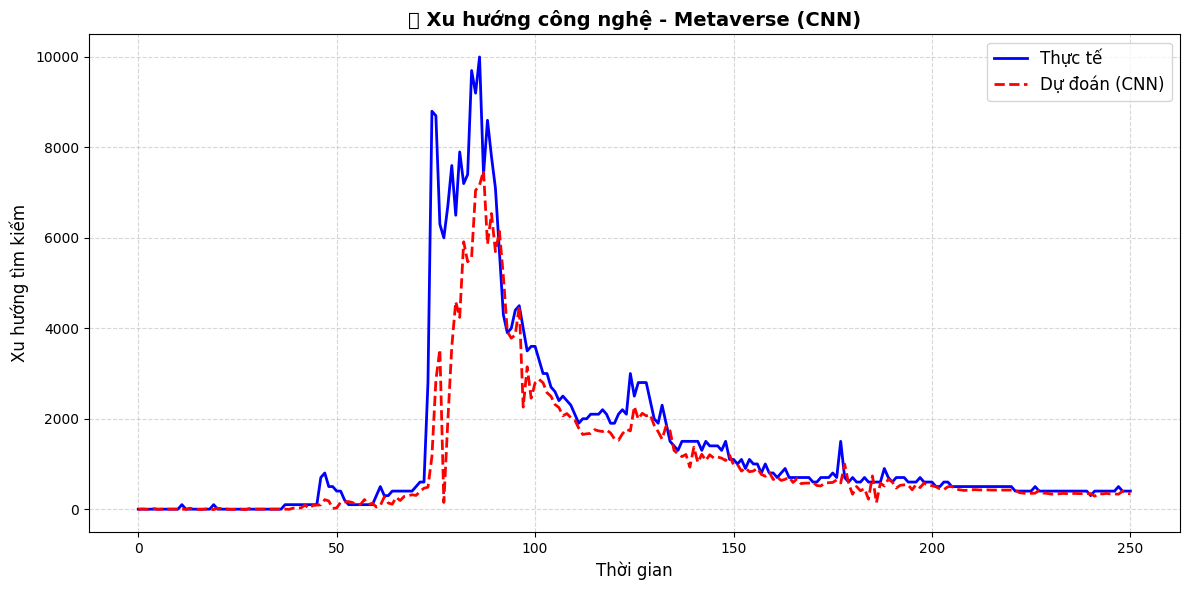

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 


<ipython-input-157-0f811f9089cf>:42: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


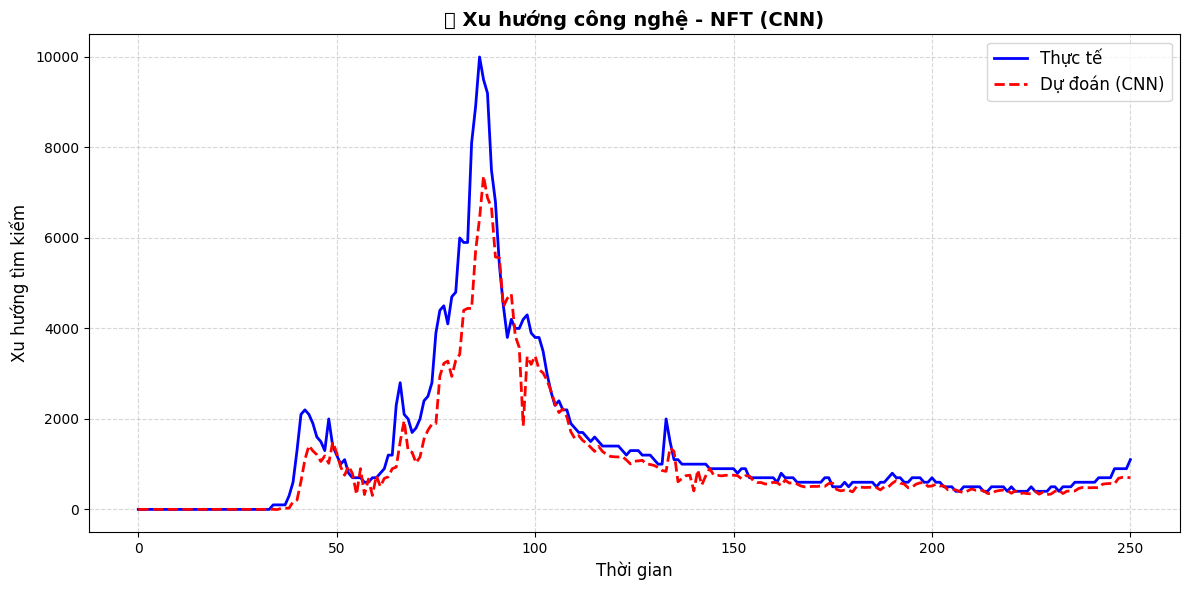

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step


<ipython-input-157-0f811f9089cf>:42: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


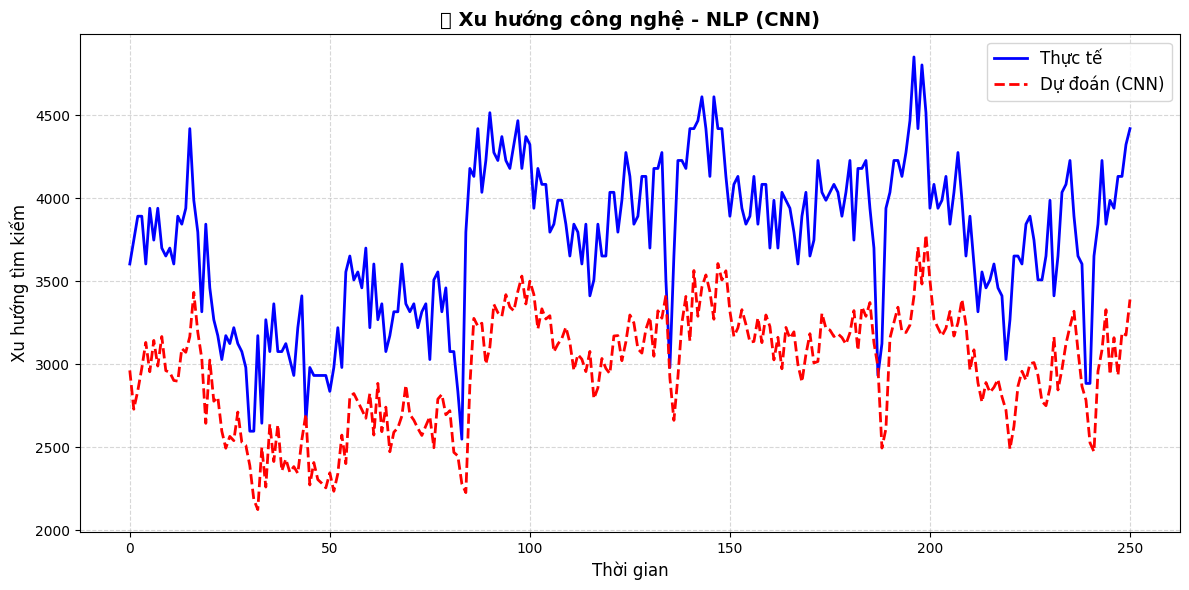

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 


<ipython-input-157-0f811f9089cf>:42: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


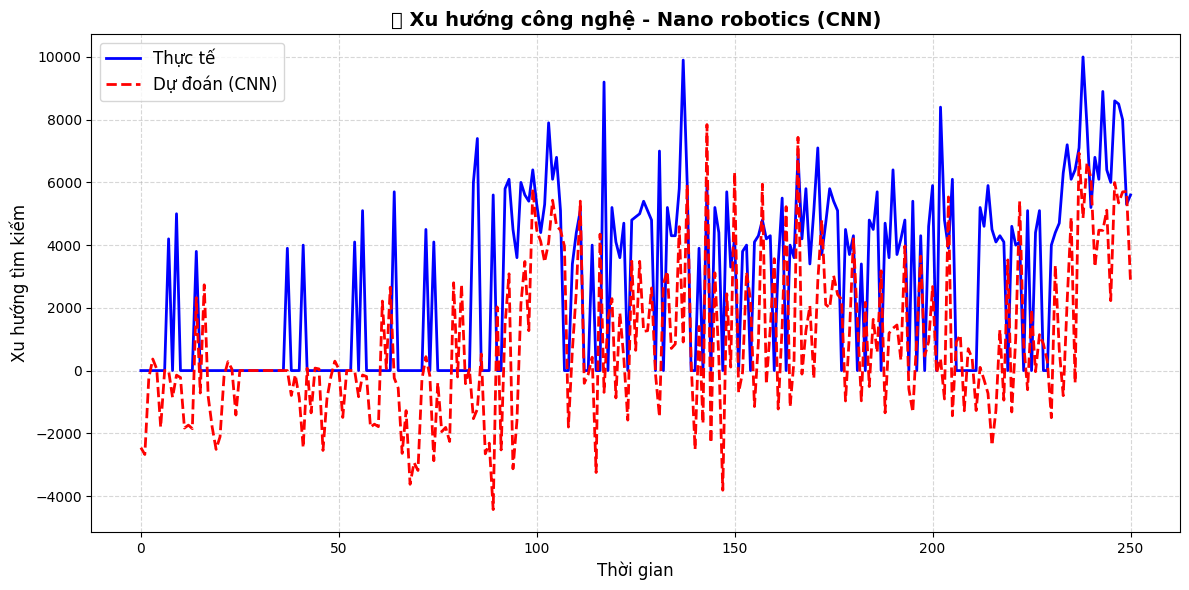

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 


<ipython-input-157-0f811f9089cf>:42: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


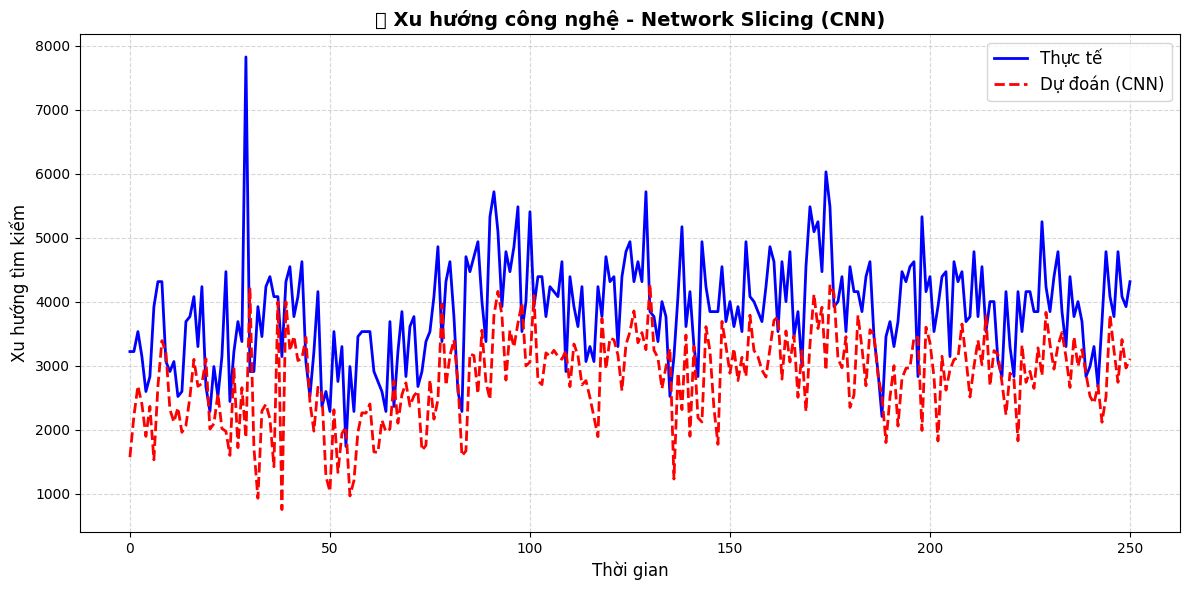

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 


<ipython-input-157-0f811f9089cf>:42: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


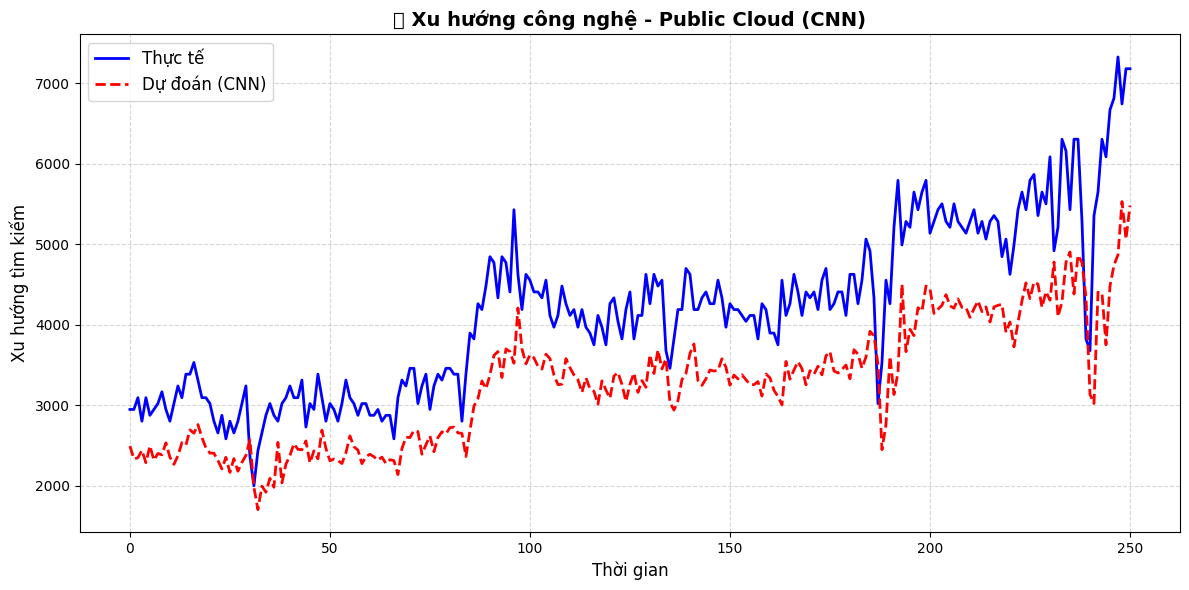

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 


<ipython-input-157-0f811f9089cf>:42: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


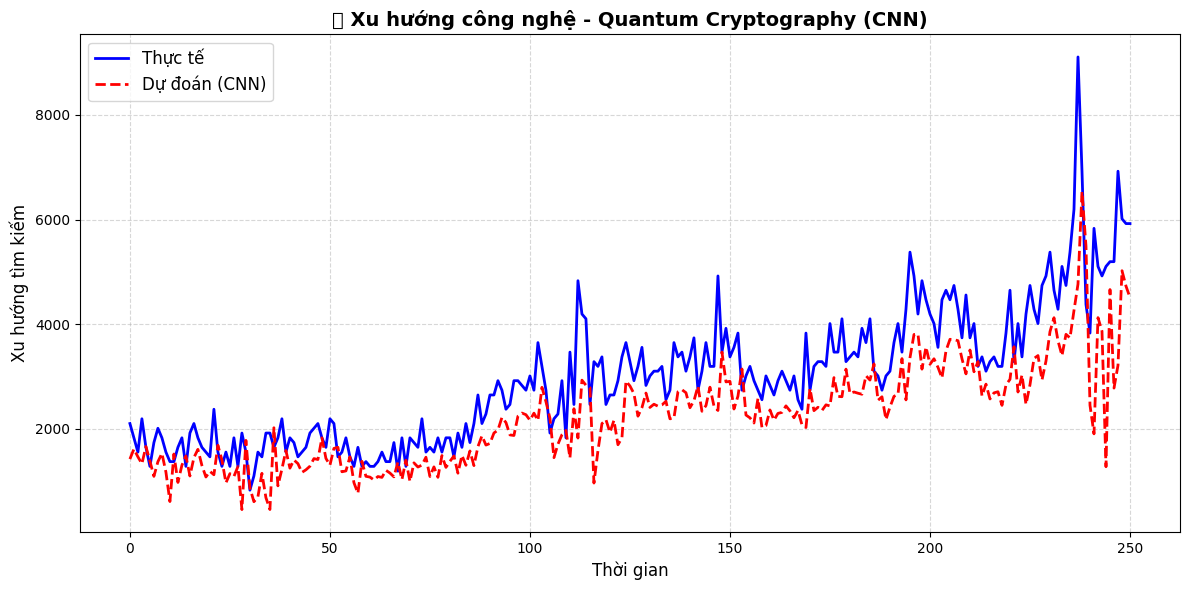

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 


<ipython-input-157-0f811f9089cf>:42: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


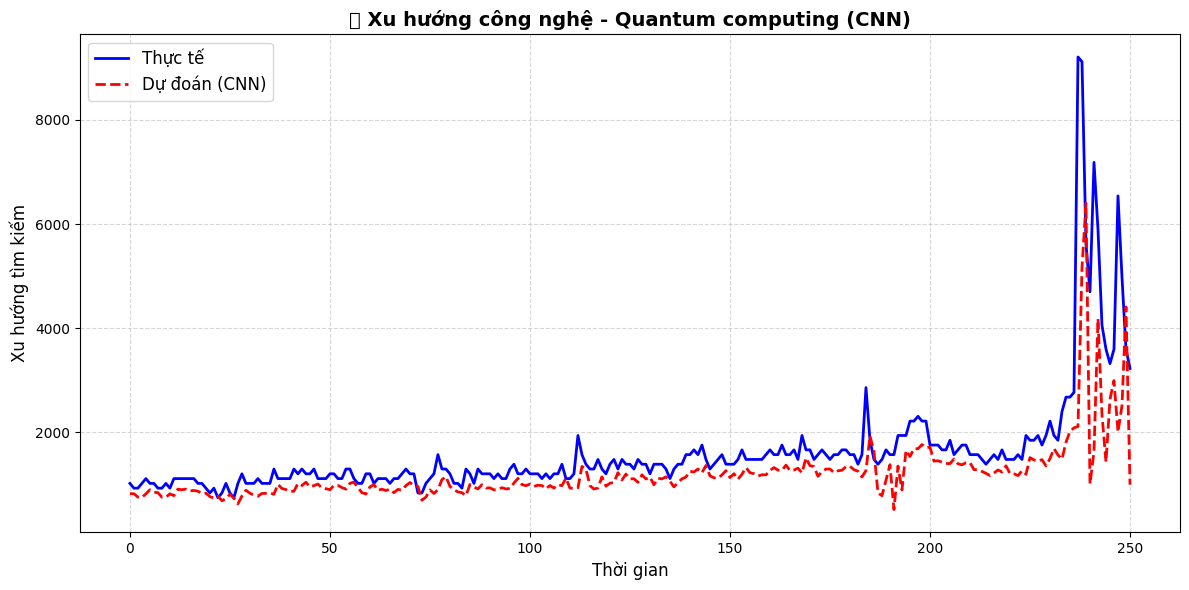

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 


<ipython-input-157-0f811f9089cf>:42: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


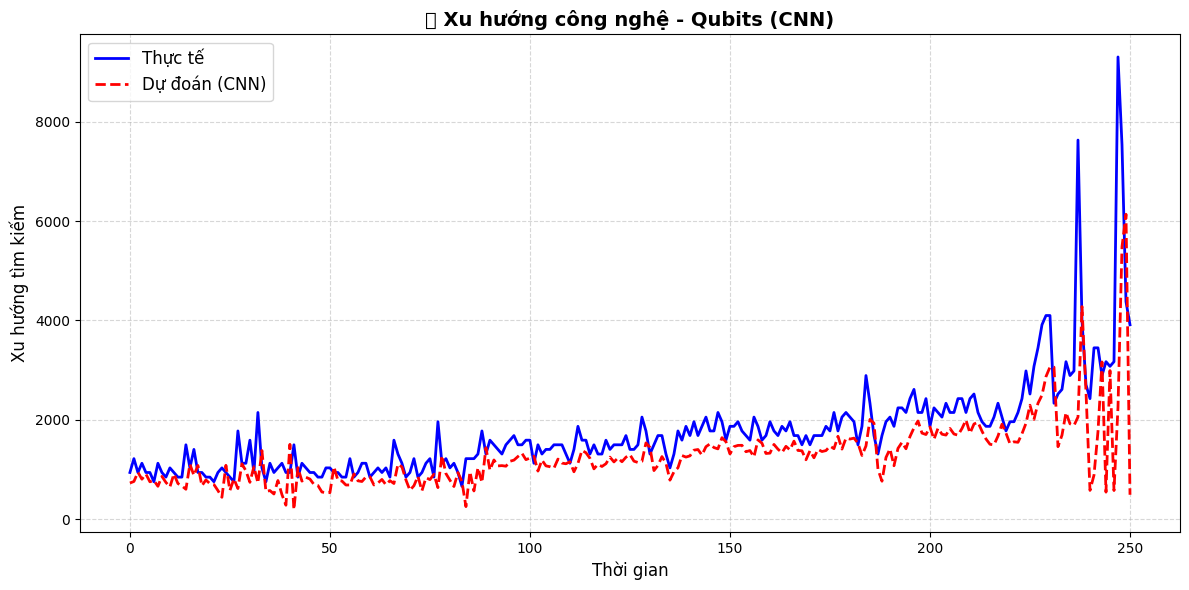

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 


<ipython-input-157-0f811f9089cf>:42: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


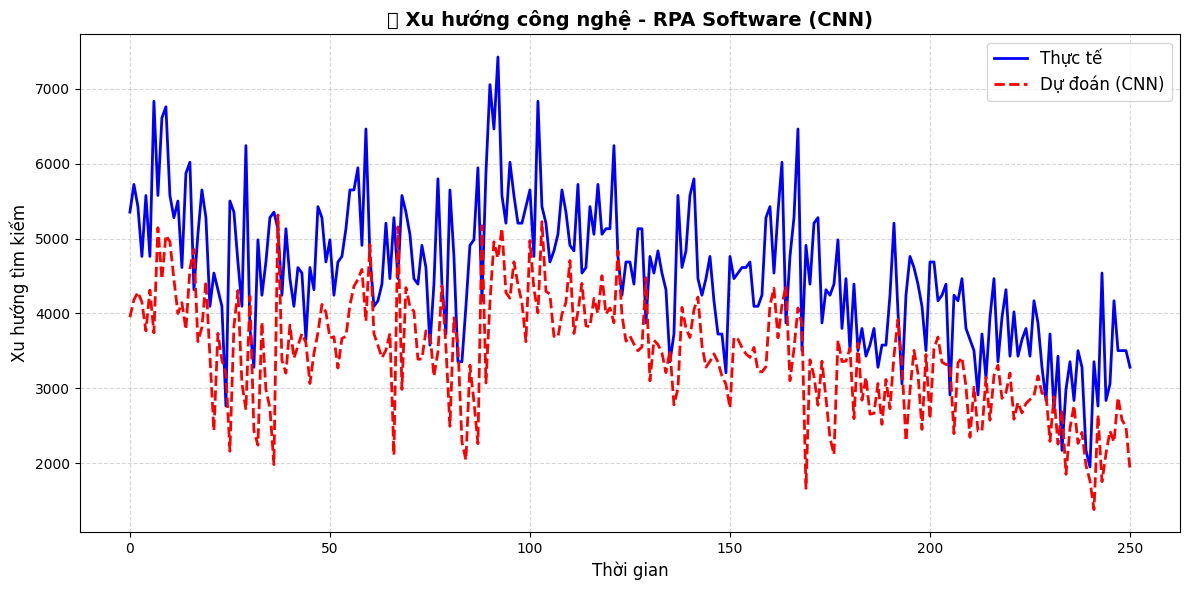

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 


<ipython-input-157-0f811f9089cf>:42: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


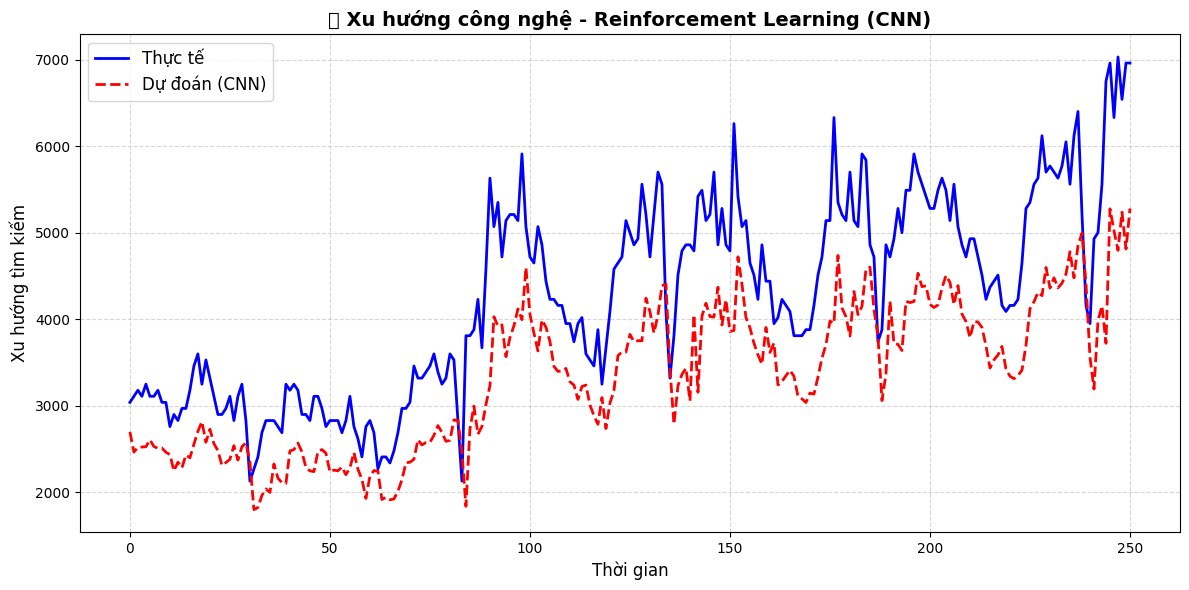

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 


<ipython-input-157-0f811f9089cf>:42: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


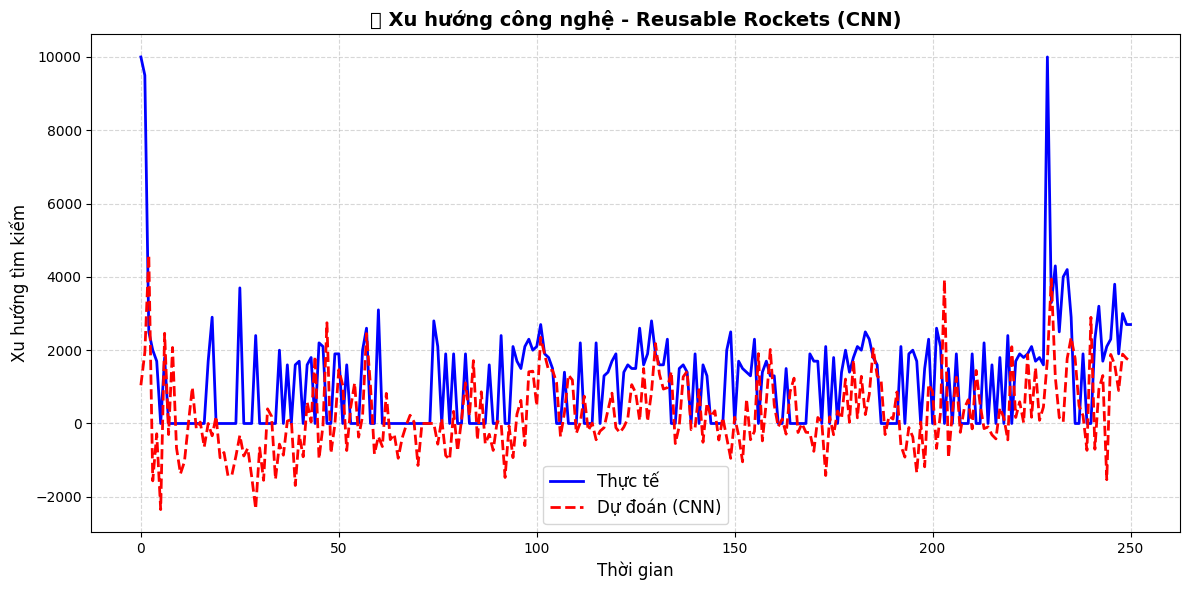

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 


<ipython-input-157-0f811f9089cf>:42: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


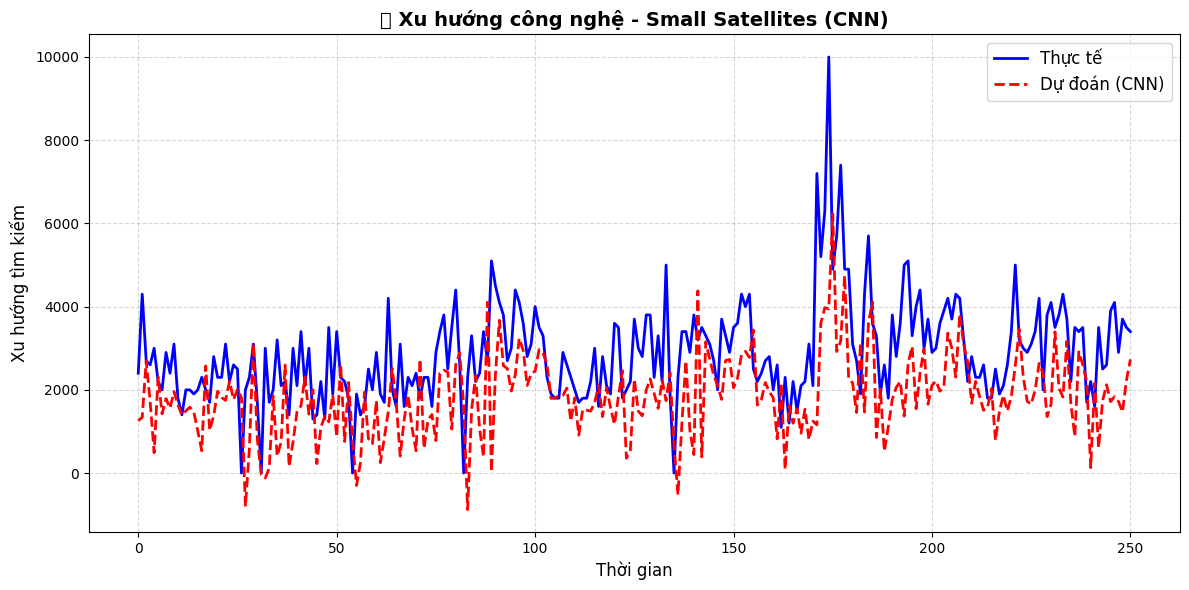

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 


<ipython-input-157-0f811f9089cf>:42: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


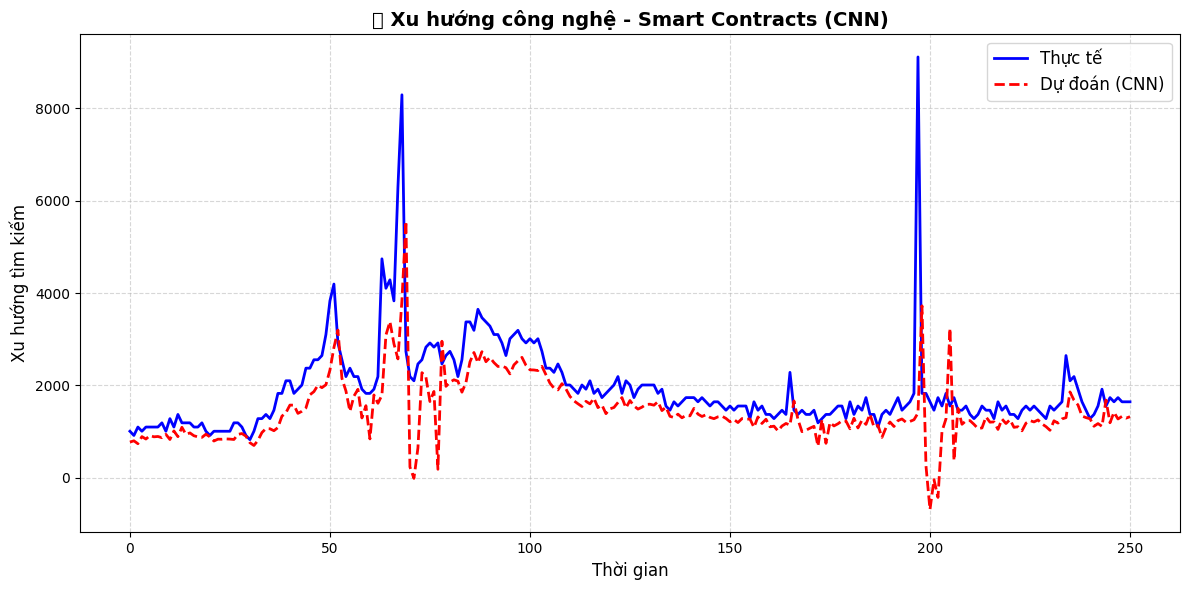

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 


<ipython-input-157-0f811f9089cf>:42: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


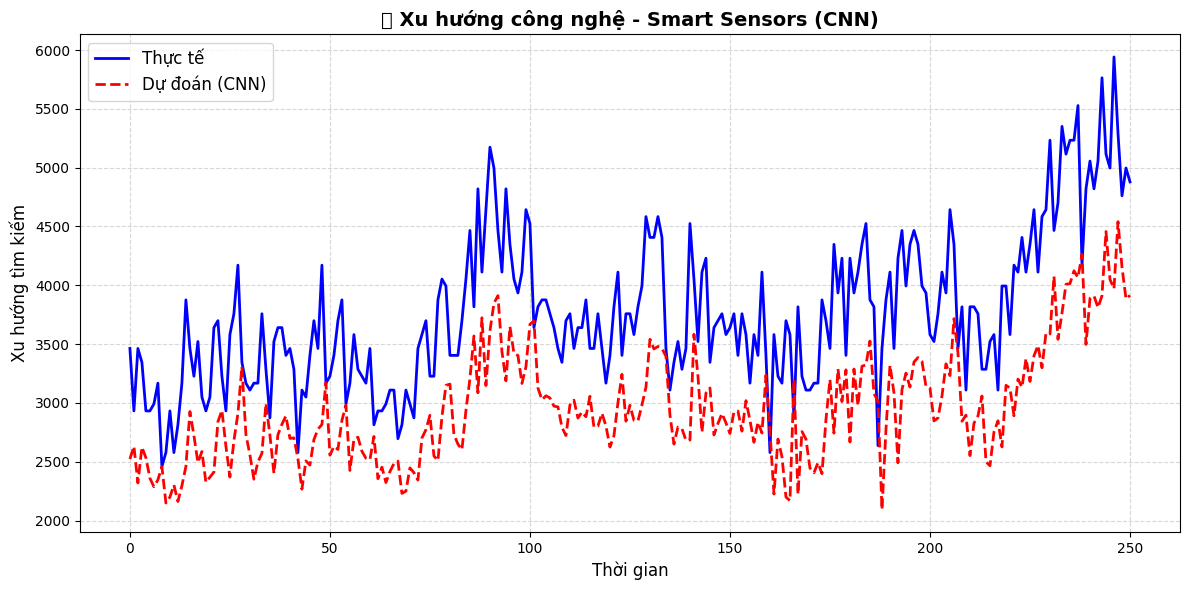

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 


<ipython-input-157-0f811f9089cf>:42: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


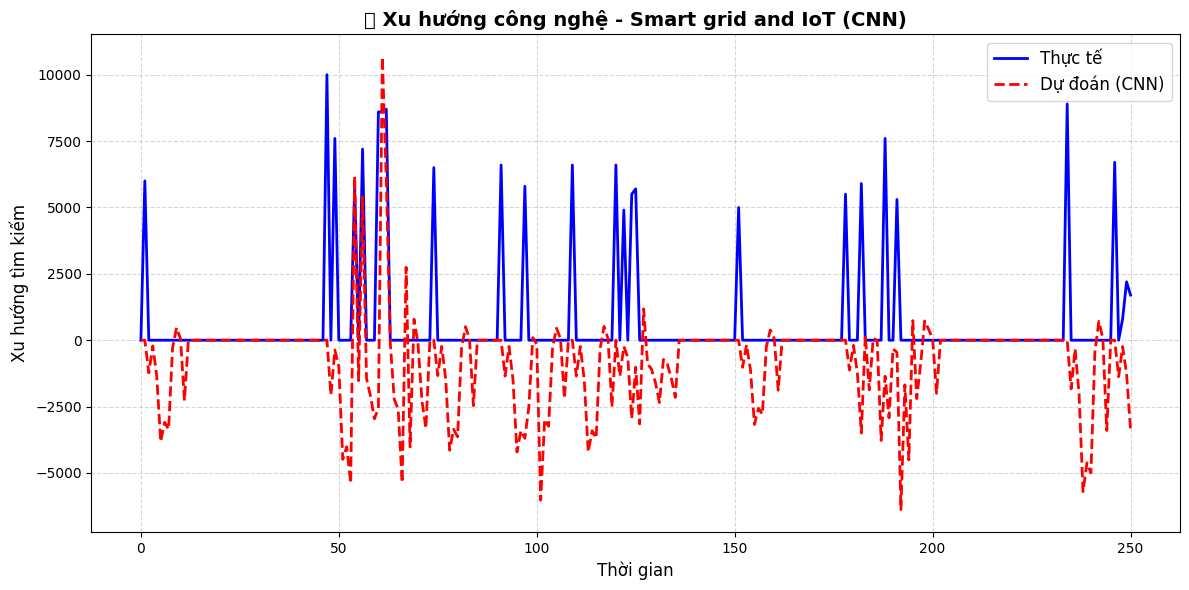

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 


<ipython-input-157-0f811f9089cf>:42: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


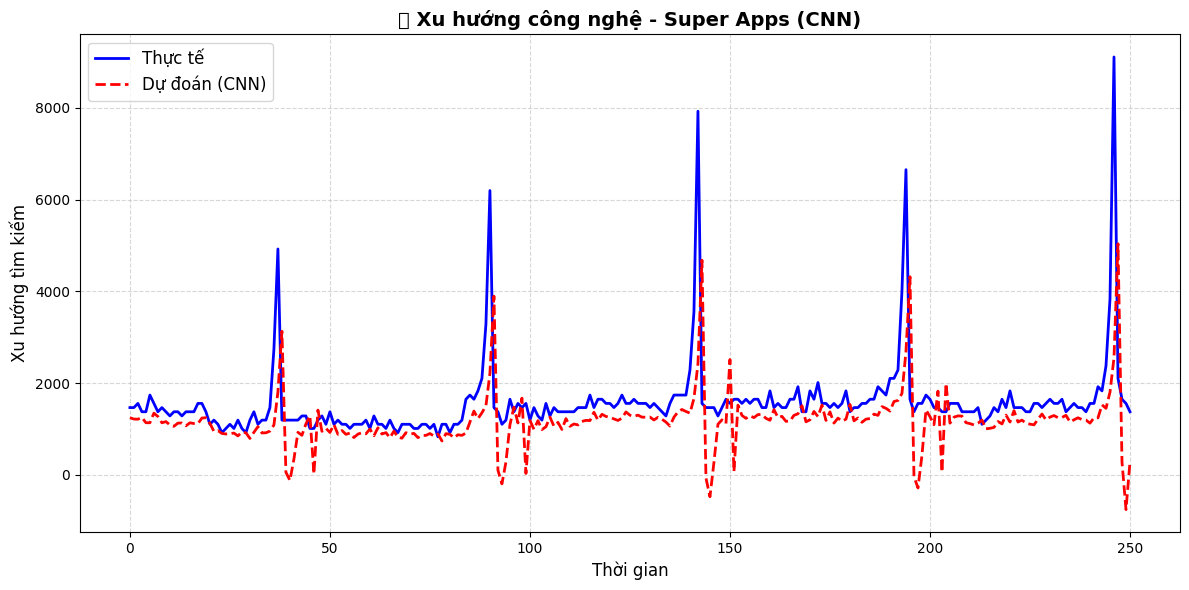

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 


<ipython-input-157-0f811f9089cf>:42: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


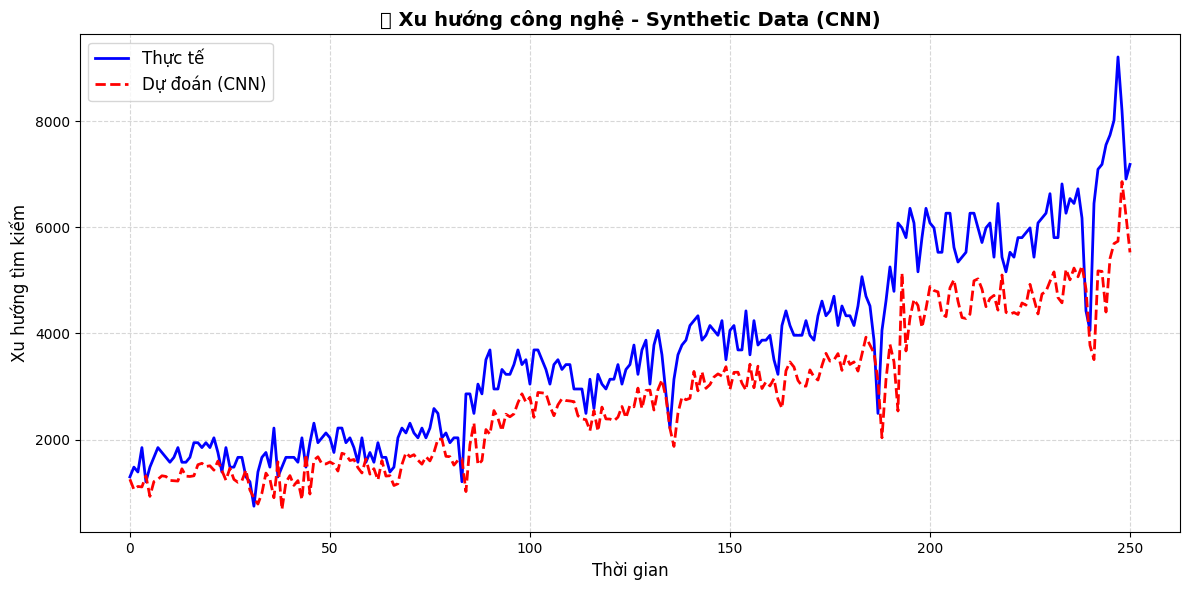

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 


<ipython-input-157-0f811f9089cf>:42: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


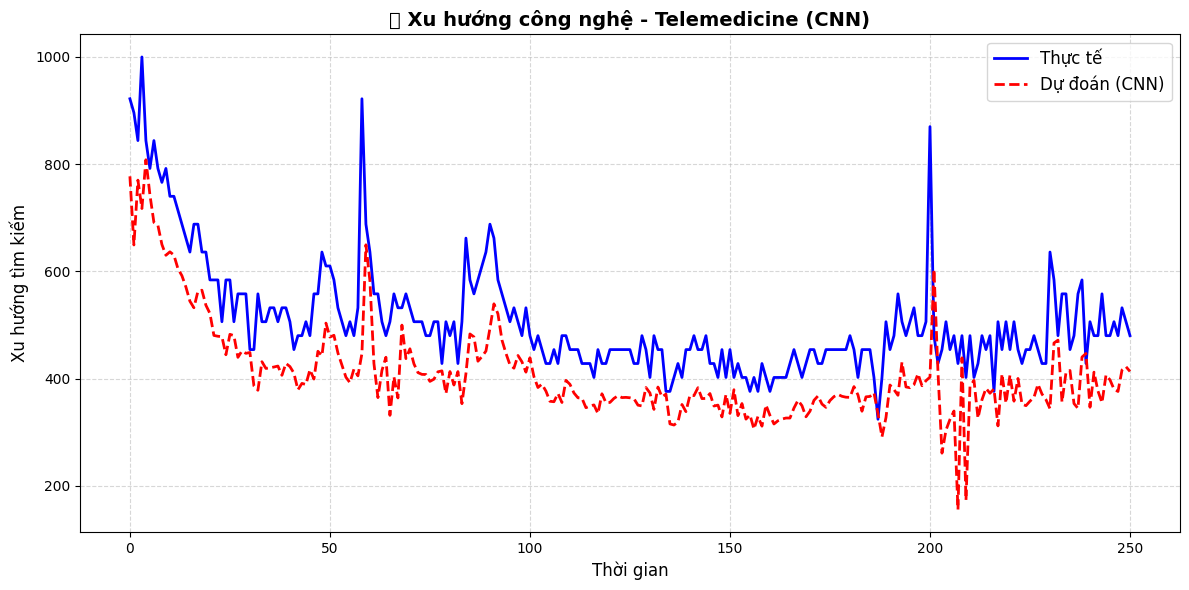

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 


<ipython-input-157-0f811f9089cf>:42: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


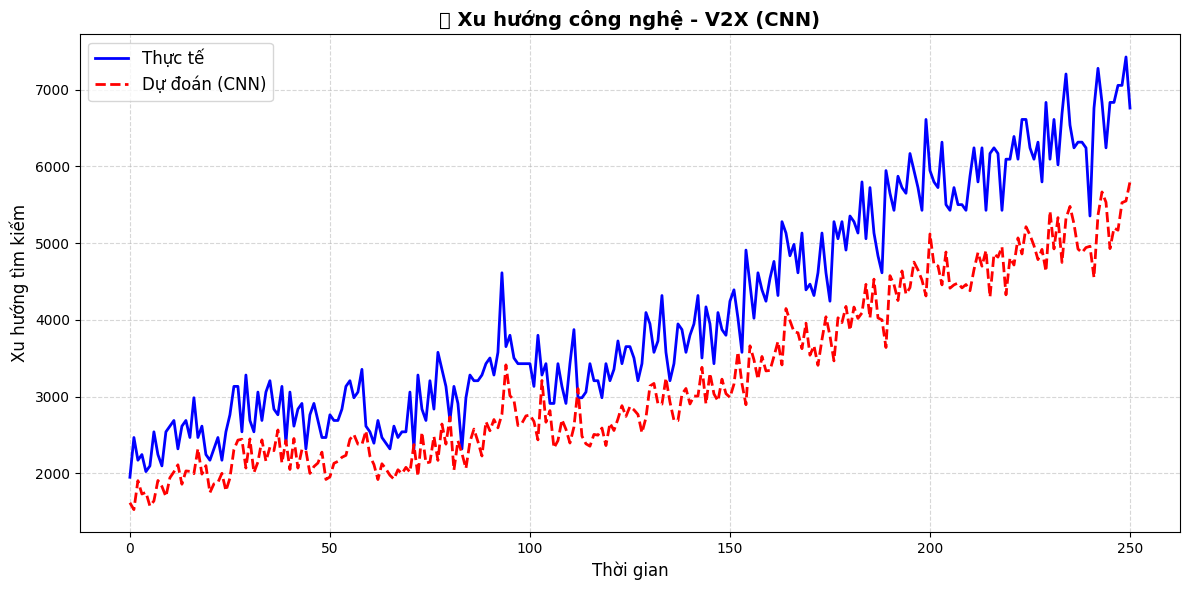

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 


<ipython-input-157-0f811f9089cf>:42: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


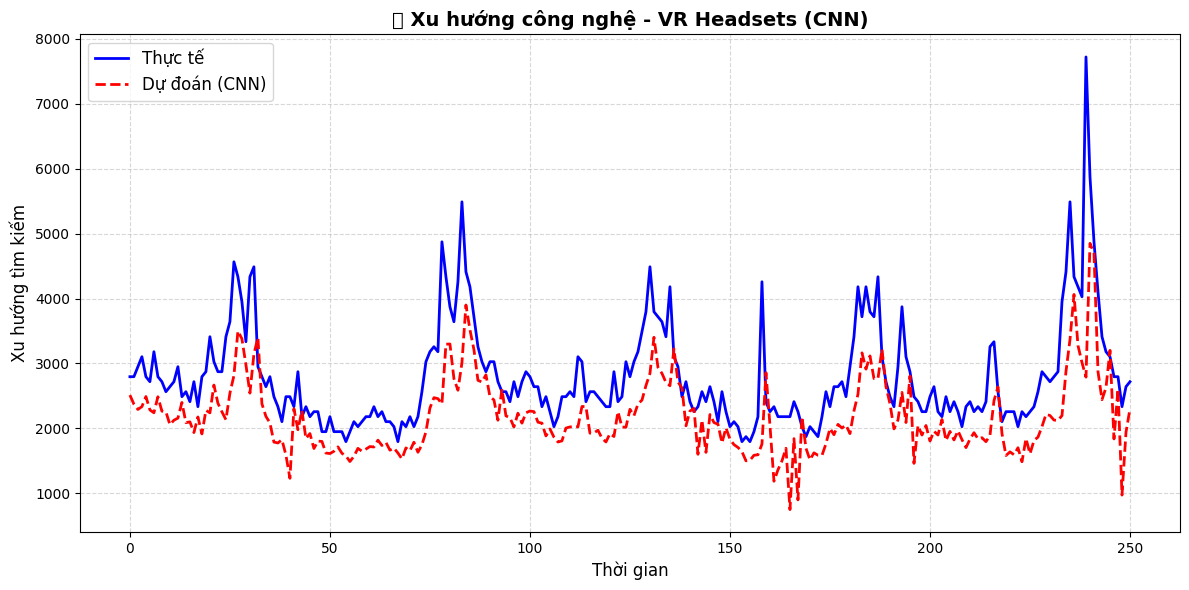

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 


<ipython-input-157-0f811f9089cf>:42: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


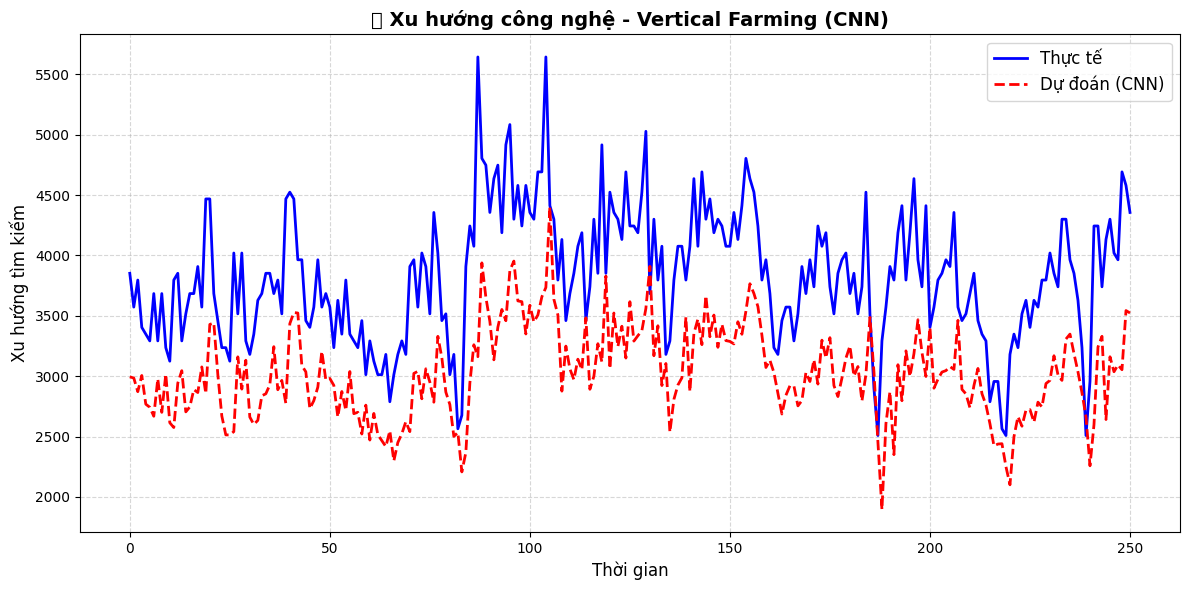

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 


<ipython-input-157-0f811f9089cf>:42: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


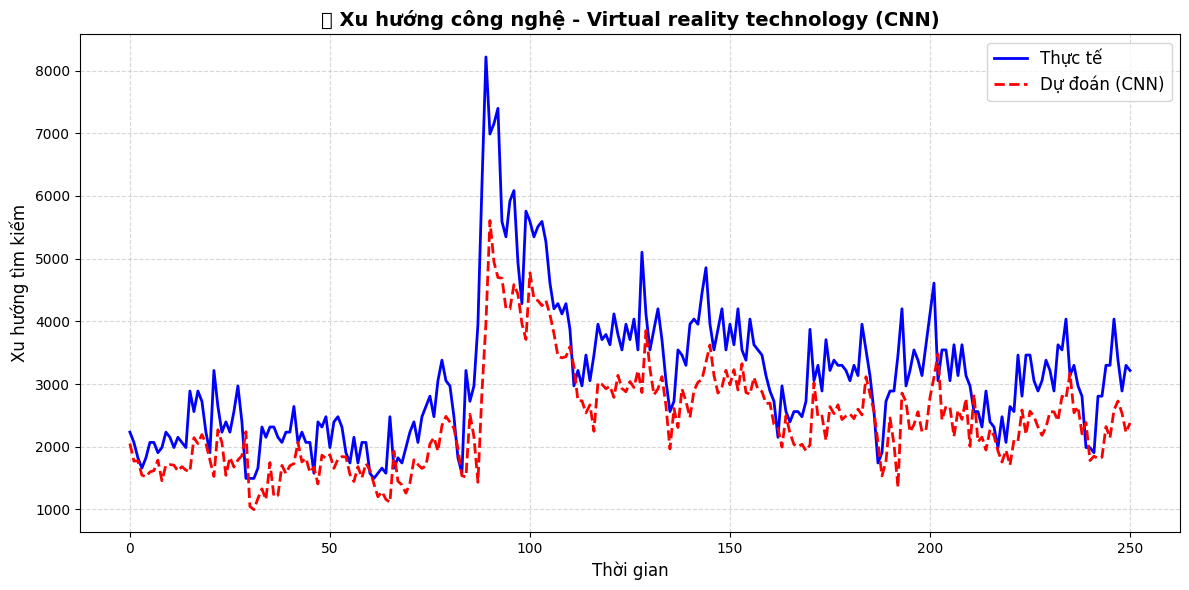

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step


<ipython-input-157-0f811f9089cf>:42: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


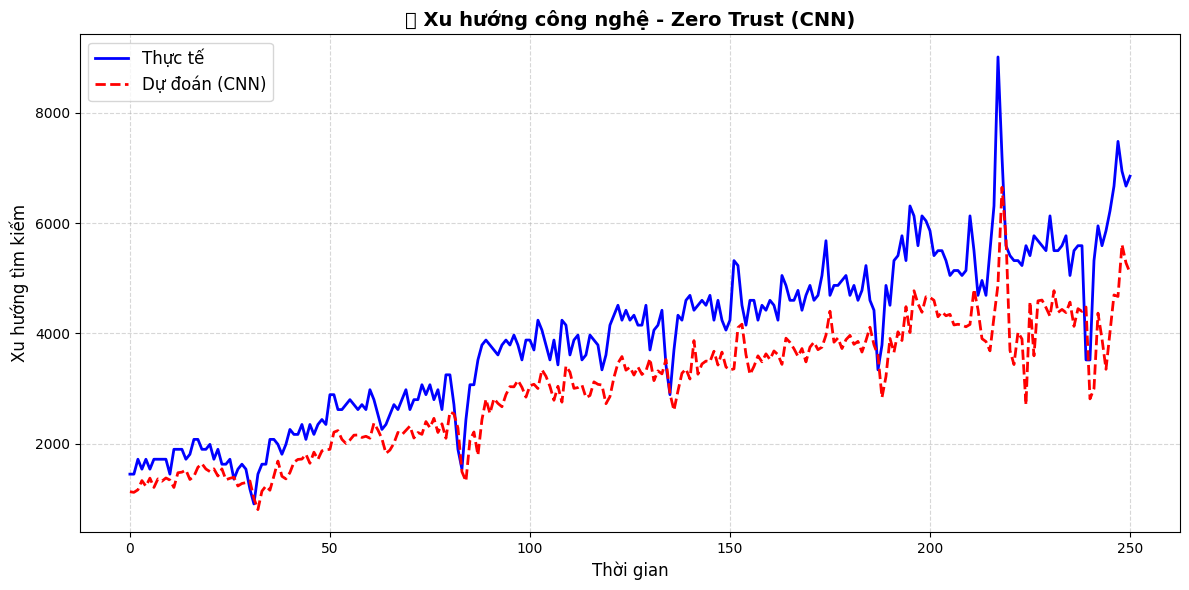

In [ ]:
import matplotlib.pyplot as plt

# Get unique keywords from the original DataFrame (df)
keywords = df['keyword'].unique()

# Define step_size here (or before the loop starts)
# step_size = 5  # You can adjust this value as needed

# Iterate through each keyword
for keyword in keywords:
    # Filter the original DataFrame (df) by keyword
    filtered_df = df[df['keyword'] == keyword]

    # Get the scaled trend values from the filtered DataFrame
    data = filtered_df['interest_over_time'].values  # Use original column name

    # Create input data for the CNN model
    X, y = create_sequences(data, window_size, step_size)
    X = X.reshape((X.shape[0], X.shape[1], 1))

    # ##### The fix is here #####
    # Fit scaler_y to the target variable before inverse_transform
    scaler_y.fit(y.reshape(-1, 1))
    # ##### End of fix #####

    # Predict using the CNN model
    y_pred = model.predict(X)

    # Invert scaling to get original values
    y_pred_original = scaler_y.inverse_transform(y_pred)
    y_test_original = scaler_y.inverse_transform(y.reshape(-1, 1))

    # Plot the results
    plt.figure(figsize=(12, 6))
    plt.plot(y_test_original, label="Thực tế", color='blue', linewidth=2)
    plt.plot(y_pred_original, label="Dự đoán (CNN)", linestyle='dashed', color='red', linewidth=2)
    plt.title(f"📈 Xu hướng công nghệ - {keyword} (CNN)", fontsize=14, fontweight='bold')
    plt.xlabel("Thời gian", fontsize=12)
    plt.ylabel("Xu hướng tìm kiếm", fontsize=12)
    plt.legend(fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()
